In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from collections import Counter
import re

In [2]:
df = pd.read_csv('../dataset/vietnam_real_estate_fnl.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          10000 non-null  int64  
 1   name                9995 non-null   str    
 2   description         9995 non-null   str    
 3   property_type_name  10000 non-null  str    
 4   province_name       10000 non-null  str    
 5   district_name       9703 non-null   str    
 6   ward_name           8570 non-null   str    
 7   street_name         6088 non-null   str    
 8   project_name        2763 non-null   str    
 9   price               9227 non-null   float64
 10  area                10000 non-null  float64
 11  floor_count         2469 non-null   float64
 12  frontage_width      5196 non-null   float64
 13  house_depth         261 non-null    float64
 14  road_width          2002 non-null   float64
 15  bedroom_count       5416 non-null   float64
 16  bathroom_count  

In [3]:
# Chuẩn hóa cột thời gian
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')

print(df.shape)
df.head()

(10000, 20)


,Unnamed: 0,name,description,property_type_name,province_name,district_name,ward_name,street_name,project_name,price,area,floor_count,frontage_width,house_depth,road_width,bedroom_count,bathroom_count,house_direction,balcony_direction,published_at
0,0,"Bán đất Thanh Đàm, ô tô vào nhà, cách phố 15m,...","Bán đất Thanh Đàm, ô tô vào nhà, cách phố 15m,...",Nhà,Hà Nội,Hoàng Mai,Thanh Trì,Thanh Đàm,NaN,1.085000e+10,70.0,NaN,5.0,14.0,NaN,NaN,NaN,NaN,NaN,2025-06-24 07:19:17.785
1,1,"Lô góc KĐT Bắc Châu Giang, 97m2, chân 34 tòa c...","Thông tin nổi bật: Diện tích: 97m², mặt tiền r...",Biệt thự/Nhà liền kề,Hà Nam,Phủ Lý,Lam Hạ,NaN,Sun Urban City Hà Nam,NaN,97.0,4.0,9.0,NaN,NaN,4.0,3.0,NaN,NaN,2025-10-21 14:34:19.757
2,2,"Siêu rẻ. Bán đất diện tích 105m2, mặt đường Ph...",Thông tin chi tiết: - Vị trí: Mặt tiền đường P...,Đất,Đà Nẵng,Ngũ Hành Sơn,Mỹ An,Phan Tôn,NaN,1.950000e+10,105.0,NaN,5.0,NaN,5.5,NaN,NaN,NaN,NaN,2025-10-16 16:20:41.601
3,3,"Bán tòa CHDV Nguyễn Thị Minh Khai, Q1 - TN: 72...",Cam Kết: Thông tin thật - Nhà còn bán - Pháp l...,Nhà,Hồ Chí Minh,1,Đa Kao,Nguyễn Thị Minh Khai,NaN,1.900000e+10,72.0,NaN,5.7,NaN,NaN,NaN,NaN,Đông Bắc,NaN,2025-06-19 02:45:17.993
4,4,Bán Đất Tặng Nhà 2 Tầng Mặt Tiền Đường Lê Quan...,Bán Đất Tặng Nhà 2 Tầng Mặt Tiền Đường Lê Quan...,Đất,Đà Nẵng,Ngũ Hành Sơn,Mỹ An,Lê Quang Đạo,NaN,4.600000e+10,128.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-29 05:40:51.815


                    missing_count  missing_pct
house_depth                  9739        97.39
balcony_direction            8445        84.45
road_width                   7998        79.98
floor_count                  7531        75.31
project_name                 7237        72.37
house_direction              6949        69.49
bathroom_count               4933        49.33
frontage_width               4804        48.04
bedroom_count                4584        45.84
street_name                  3912        39.12
ward_name                    1430        14.30
price                         773         7.73
district_name                 297         2.97
published_at                   14         0.14
description                     5         0.05
name                            5         0.05
Unnamed: 0                      0         0.00
province_name                   0         0.00
property_type_name              0         0.00
area                            0         0.00


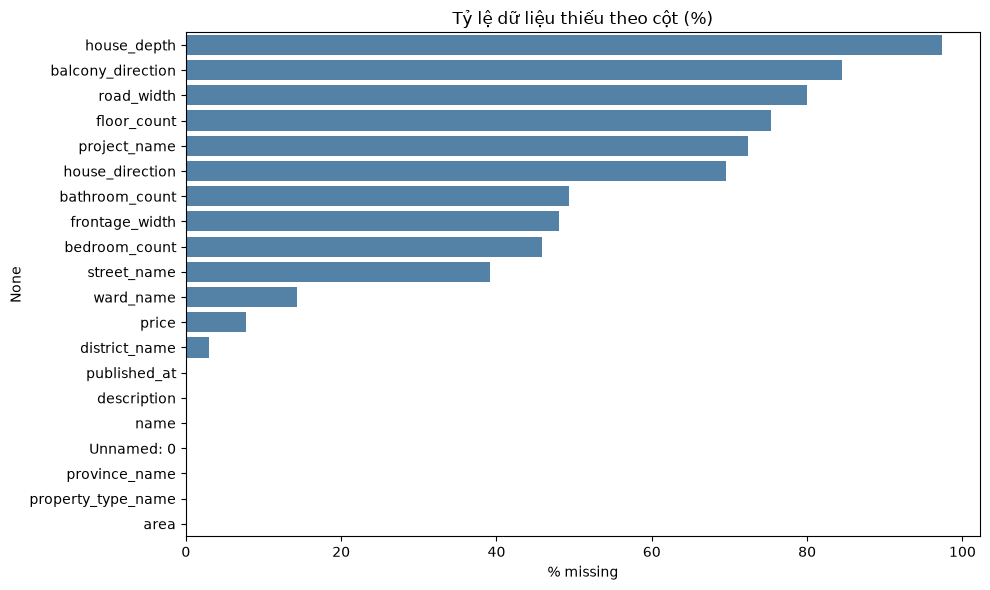

In [4]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

print(missing)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing['missing_pct'], y=missing.index, color='steelblue')
plt.title('Tỷ lệ dữ liệu thiếu theo cột (%)')
plt.xlabel('% missing')
plt.tight_layout()
plt.show()

Dữ liệu không có dòng trùng lặp hoàn toàn (0 dòng). Xét trùng theo các trường mô tả chính (tên, mô tả, giá, diện tích, tỉnh/quận) chỉ phát hiện 5 tin nghi trùng (~0.05% tổng số) — tỷ lệ rất nhỏ, không ảnh hưởng đáng kể đến phân tích.

In [ ]:
# KIỂM TRA DỮ LIỆU TRÙNG LẶP + LOẠI CỘT THỪA
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
 
n_dup_full = df.duplicated().sum()
print(f"Số dòng trùng lặp hoàn toàn: {n_dup_full}")
 
# Trùng lặp dựa trên các trường mô tả tin đăng (khả năng đăng lại nhiều lần)
subset_cols = ['name', 'description', 'price', 'area', 'province_name', 'district_name']
n_dup_subset = df.duplicated(subset=subset_cols).sum()
print(f"Số tin đăng có thể là trùng lặp (dựa trên name/description/price/area/địa chỉ): {n_dup_subset}")
 

Số dòng trùng lặp hoàn toàn: 0
Số tin đăng có thể là trùng lặp (dựa trên name/description/price/area/địa chỉ): 5


area và price không có giá trị âm/bằng 0 — sạch ở 2 trường quan trọng nhất. Tuy nhiên có 30 tin với số phòng ngủ > 20 và 23 tin với số phòng tắm > 20, nhiều khả năng là lỗi nhập liệu chứ không phải BĐS thực tế. Nên cân nhắc loại bỏ các dòng này trước khi đưa vào mô hình vì chúng có thể làm méo mối quan hệ giữa số phòng và giá.

In [6]:
# KIỂM TRA GIÁ TRỊ BẤT HỢP LỆ (SANITY CHECK)
sanity_checks = {
    'area <= 0': (df['area'] <= 0).sum(),
    'price <= 0 (trong số có giá trị)': (df['price'] <= 0).sum(),
    'bedroom_count > 20': (df['bedroom_count'] > 20).sum(),
    'bathroom_count > 20': (df['bathroom_count'] > 20).sum(),
    'floor_count > 50': (df['floor_count'] > 50).sum(),
}
print("--- Kiểm tra giá trị bất thường ---")
for k, v in sanity_checks.items():
    print(f"{k}: {v}")

--- Kiểm tra giá trị bất thường ---
area <= 0: 0
price <= 0 (trong số có giá trị): 0
bedroom_count > 20: 30
bathroom_count > 20: 23
floor_count > 50: 0


Theo IQR, frontage_width có tỷ lệ outlier cao nhất (11.22%), tiếp theo là area (10.05%) và price (9.91%) — đúng với các biến có phân phối lệch phải mạnh nhất. Ngược lại floor_count có tỷ lệ outlier thấp nhất (0.93%), cho thấy số tầng khá đồng đều giữa các tin đăng. Đây là cơ sở để ưu tiên xử lý outlier (winsorize/log-transform) cho price, area, frontage_width trước khi mô hình hoá.

           column  n_non_null  n_outliers  pct_outliers   lower_bound  \
3  frontage_width        5196         583         11.22 -4.500000e-01   
1            area       10000        1005         10.05 -4.250000e+01   
0           price        9227         914          9.91 -1.058350e+10   
4     house_depth         261          21          8.05 -3.630000e+00   
5      road_width        2002         137          6.84 -5.750000e+00   
6   bedroom_count        5416         151          2.79 -1.000000e+00   
7  bathroom_count        5067         119          2.35 -1.000000e+00   
2     floor_count        2469          23          0.93  0.000000e+00   

    upper_bound  
3  1.195000e+01  
1  2.175000e+02  
0  2.857250e+10  
4  4.058000e+01  
5  2.025000e+01  
6  7.000000e+00  
7  7.000000e+00  
2  8.000000e+00  


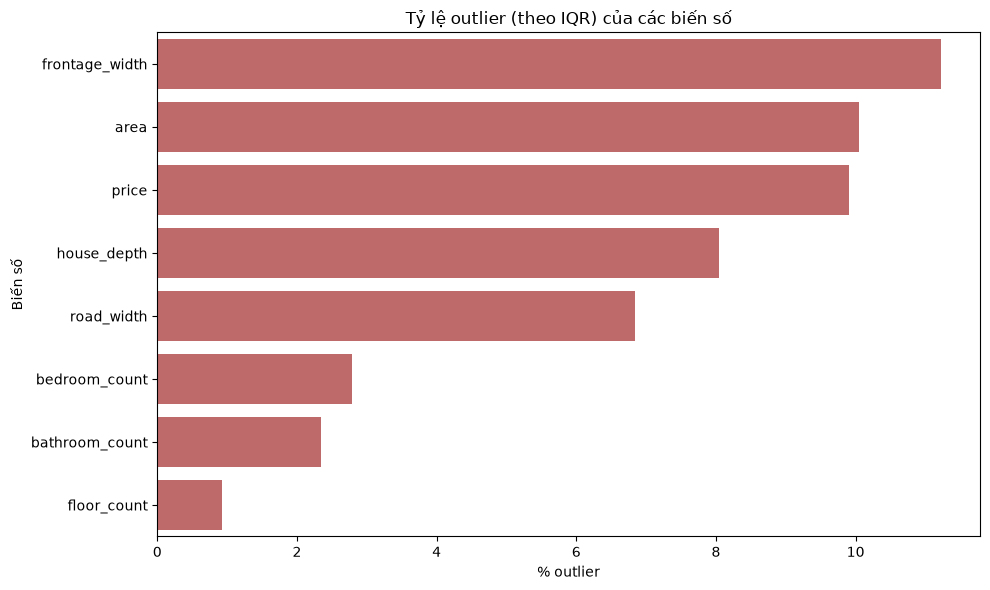

In [7]:
#  OUTLIER DETECTION CÓ HỆ THỐNG (IQR) CHO CÁC BIẾN SỐ CHÍNH
numeric_cols = ['price', 'area', 'floor_count', 'frontage_width',
                 'house_depth', 'road_width', 'bedroom_count', 'bathroom_count']
 
outlier_summary = []
for col in numeric_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append({
        'column': col,
        'n_non_null': len(s),
        'n_outliers': n_outliers,
        'pct_outliers': round(n_outliers / len(s) * 100, 2) if len(s) > 0 else 0,
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
    })
 
outlier_df = pd.DataFrame(outlier_summary).sort_values('pct_outliers', ascending=False)
print(outlier_df)
 
plt.figure(figsize=(10, 6))
sns.barplot(data=outlier_df, x='pct_outliers', y='column', color='indianred')
plt.title('Tỷ lệ outlier (theo IQR) của các biến số')
plt.xlabel('% outlier')
plt.ylabel('Biến số')
plt.tight_layout()
plt.show()
 

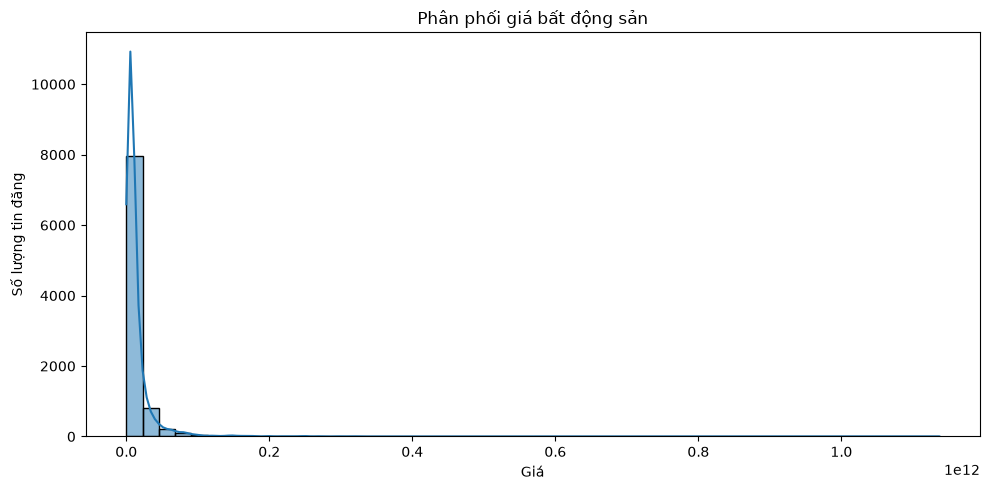

In [8]:
# biểu đồ xem và phân tích độ outline của giá, vì có nhiều giá bds quá chênh lệch
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="price",
    bins=50,
    kde=True
)

plt.title("Phân phối giá bất động sản")
plt.xlabel("Giá")
plt.ylabel("Số lượng tin đăng")

plt.tight_layout()
plt.show()

Biểu đồ trên cho thấy là giá bds của những tin đăng lệch rất mạnh, bị outline khá là nhiều

In [9]:
# SKEWNESS & KURTOSIS
skew_kurt = pd.DataFrame({
    'skewness': df[numeric_cols].skew(),
    'kurtosis': df[numeric_cols].kurtosis(),
}).round(2).sort_values('skewness', ascending=False)
 
print("--- Độ lệch (skewness) và độ nhọn (kurtosis) ---")
print(skew_kurt)
# skewness > 1: lệch phải mạnh (đuôi dài bên phải)
# kurtosis cao: phân phối có nhiều outlier / đuôi dày hơn phân phối chuẩn

--- Độ lệch (skewness) và độ nhọn (kurtosis) ---
                skewness  kurtosis
area               30.39   1191.67
road_width         15.12    317.62
price              14.20    371.41
frontage_width     11.83    223.59
bathroom_count      8.85    133.89
bedroom_count       7.75     97.38
house_depth         3.62     17.63
floor_count         0.49      0.52


area có độ lệch cực đoan (skewness = 30.39, kurtosis = 1191.67) — cao vượt trội so với các biến còn lại, cho thấy một số ít BĐS diện tích siêu lớn đang kéo dài đuôi phân phối. price cũng lệch phải mạnh (skewness = 14.20). Ngược lại floor_count gần với phân phối chuẩn nhất (skewness = 0.49). Kết quả này khẳng định cần log-transform hoặc xử lý outlier cho area và price trước khi đưa vào các mô hình nhạy với phân phối.

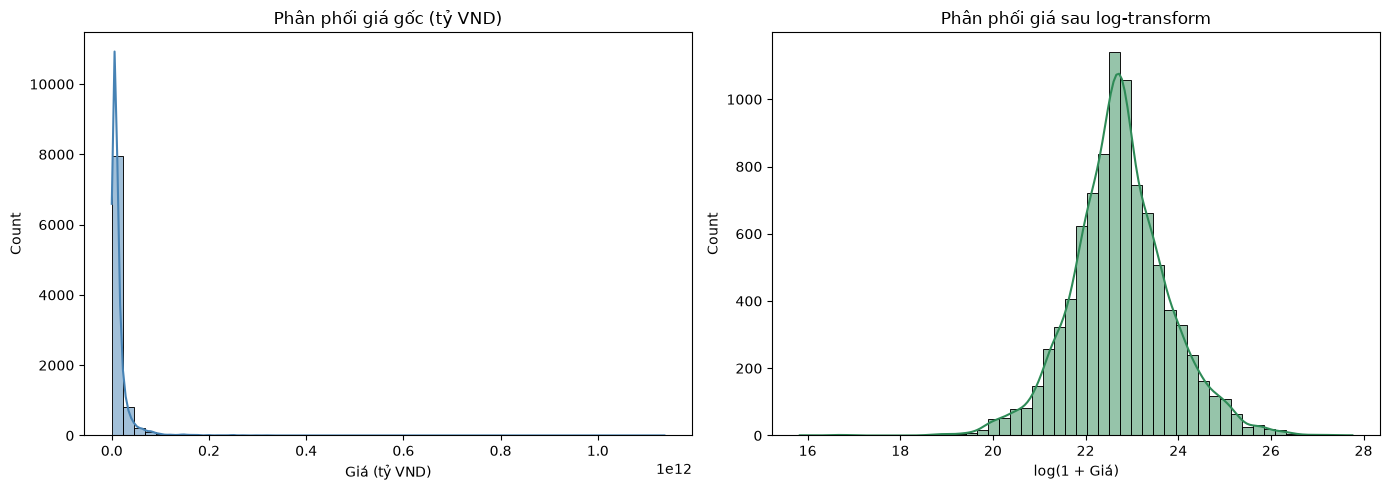

Skewness giá gốc: 14.20
Skewness sau log-transform: 0.04


In [10]:
# LOG-TRANSFORM GIÁ (do phân phối lệch phải rất mạnh)-
df_price = df[['price']].copy()
df_log = df_price.copy()
df_log['log_price'] = np.log1p(df_log['price'])
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.histplot(df_log['price'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Phân phối giá gốc (tỷ VND)')
axes[0].set_xlabel('Giá (tỷ VND)')
 
sns.histplot(df_log['log_price'], bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Phân phối giá sau log-transform')
axes[1].set_xlabel('log(1 + Giá)')
 
plt.tight_layout()
plt.show()
 
print(f"Skewness giá gốc: {df_log['price'].skew():.2f}")
print(f"Skewness sau log-transform: {df_log['log_price'].skew():.2f}")

Log-transform giúp giảm skewness của giá từ 14.20 xuống chỉ còn 0.04 — gần như đối xứng hoàn toàn, xác nhận log(price) là lựa chọn phù hợp làm biến mục tiêu khi xây mô hình dự đoán giá thay vì dùng giá gốc.
(Lưu ý kỹ thuật: nên sửa nhãn trục hoặc chia price cho 1e9 để khớp đơn vị "tỷ VND" hiển thị.)

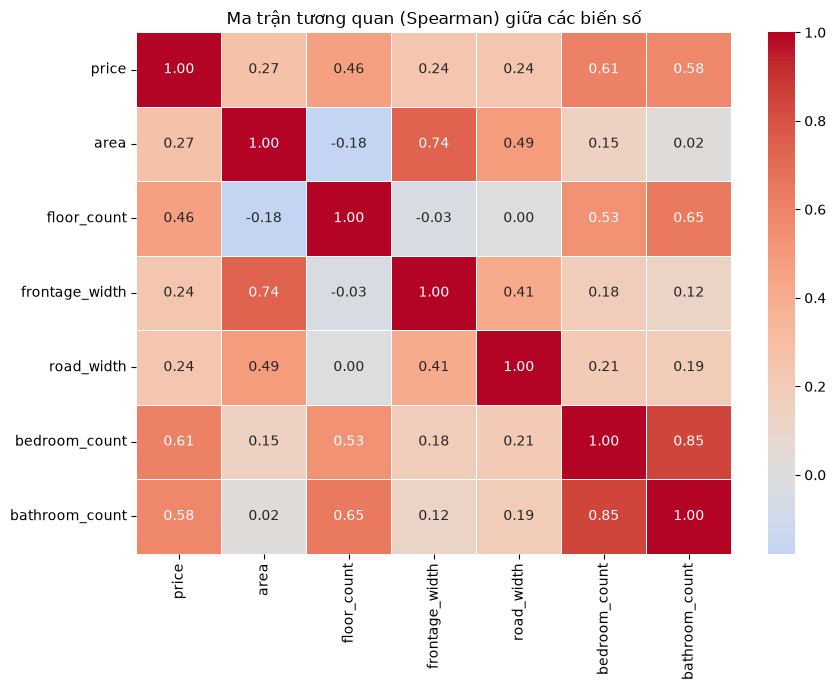

In [11]:
# MA TRẬN TƯƠNG QUAN (CORRELATION HEATMAP) GIỮA CÁC BIẾN SỐ
corr_cols = ['price', 'area', 'floor_count', 'frontage_width',
             'road_width', 'bedroom_count', 'bathroom_count']
corr_matrix = df[corr_cols].corr(method='spearman')  # Spearman vì dữ liệu lệch/nhiều outlier
 
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
)
plt.title("Ma trận tương quan (Spearman) giữa các biến số")
plt.tight_layout()
plt.show()

Vài điểm đáng chú ý từ ma trận tương quan Spearman:

- bedroom_count và bathroom_count tương quan rất mạnh (0.85) — dấu hiệu đa cộng tuyến, cần lưu ý nếu dùng hồi quy tuyến tính.

- Với giá, 2 biến tương quan mạnh nhất là bedroom_count (0.61) và bathroom_count (0.58) — mạnh hơn cả area (0.27), cho thấy số phòng phản ánh giá trị BĐS rõ hơn diện tích thô.
area và floor_count tương quan âm nhẹ (-0.18), hợp lý vì đất/nhà diện tích lớn thường thấp tầng, còn chung cư/nhà ống diện tích nhỏ nhưng nhiều tầng.

## Phân tích Giá và Diện tích


In [12]:
df_price = df.dropna(subset=["price", "area"]).copy()

df_price = df_price[
    (df_price["price"] > 0) &
    (df_price["area"] > 0)
]
df_price["price"] = df_price["price"]/1e+9

# Đơn giá trên mỗi m2
df_price["price_per_m2"] = (df_price["price"] / df_price["area"])
price_by_type = (
    df_price
    .groupby("property_type_name")
    .agg(
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        avg_area=("area", "mean"),
        median_area=("area", "median"),
        avg_price_per_m2=("price_per_m2", "mean"),
        median_price_per_m2=("price_per_m2", "median"),
        count=("price_per_m2", "count")
    )
    .sort_values("avg_price_per_m2", ascending=False)
)

price_by_type

,avg_price,median_price,avg_area,median_area,avg_price_per_m2,median_price_per_m2,count
property_type_name,,,,,,,
Nhà,15.840964,8.90,84.272994,60.25,0.192397,0.166667,4318
Biệt thự/Nhà liền kề,30.004602,18.90,178.628161,140.00,0.177959,0.154286,685
Shophouse,14.712443,8.90,110.848792,100.00,0.127145,0.089286,149
Căn hộ chung cư,6.762154,4.85,81.672697,73.00,0.075431,0.067583,1891
Đất,11.882874,4.50,596.073535,114.70,0.058935,0.036446,2184


**Điểm đáng lưu ý:** tất cả các nhóm đều có **Mean** thấp hơn hẳn **Median**, điều này chứng to tập dữ liệu có xu hướng lệch phải. Ví dụ với **Biệt thự/Nhà liền kề** có outlier chênh lệch rõ ràng nhất giữa giá trung bình và giá trung vị với **11,1 tỷ**, điều này nghĩa là BĐS điển hình trong loại hình này có mức giá gần với 18,9 tỷ hơn là 30 tỷ

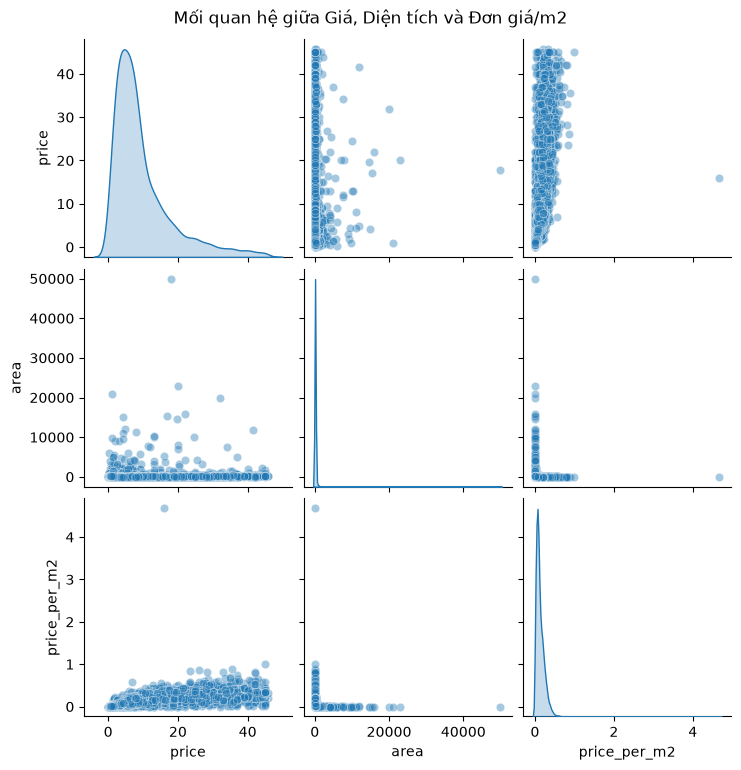

In [13]:
# PAIRPLOT CHO CÁC BIẾN SỐ CHÍNH (sau khi lọc outlier cơ bản)
pair_data = df_price[df_price['price'] < df_price['price'].quantile(0.95)]

pair_cols = ['price', 'area', 'price_per_m2']
 
sns.pairplot(pair_data[pair_cols].dropna(), diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle("Mối quan hệ giữa Giá, Diện tích và Đơn giá/m2", y=1.02)
plt.show()

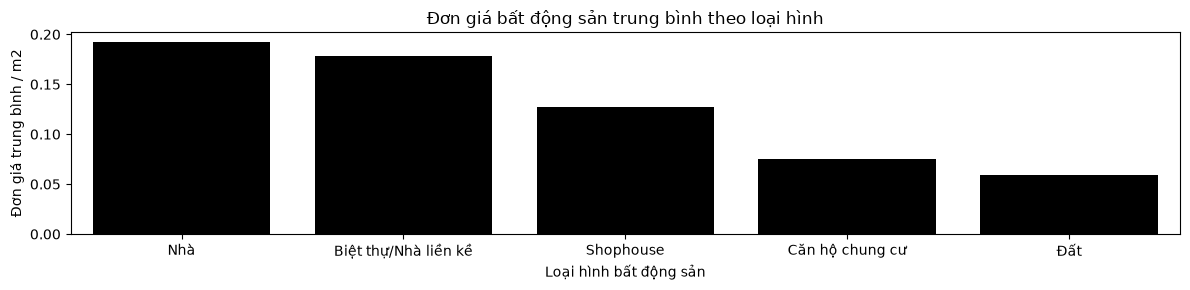

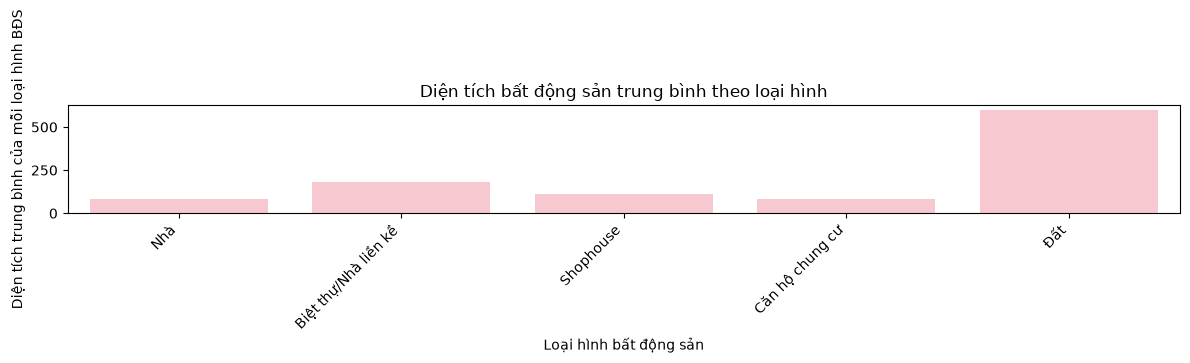

In [14]:
# Biếu đồ giá / m2 theo loại hình BĐS
plt.figure(figsize=(12, 3))
sns.barplot(
    data=price_by_type.reset_index(),
    x="property_type_name",
    y="avg_price_per_m2",
    color="black"
)
plt.xlabel("Loại hình bất động sản")
plt.ylabel("Đơn giá trung bình / m2")
plt.title("Đơn giá bất động sản trung bình theo loại hình")
plt.tight_layout()
plt.show()

# Biểu đồ diện tích trung bình theo loại hình BĐS
plt.figure(figsize=(12, 3))
sns.barplot(
    data=price_by_type.reset_index(),
    x="property_type_name",
    y="avg_area",
    color="pink"
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Loại hình bất động sản")
plt.ylabel("Diện tích trung bình của mỗi loại hình BĐS")
plt.title("Diện tích bất động sản trung bình theo loại hình")
plt.tight_layout()
plt.show()

### Sự tương quan giữa giá trung bình, giá trên mỗi mét vuông và diện tích
****Nhà**** có đơn giá trung bình cao nhất, khoảng ****192,4 triệu đồng/m².****

****Biệt thự/Nhà liền kề**** đứng thứ hai với khoảng ****178,0 triệu đồng/m².****

****Shophouse**** có đơn giá khoảng ****127,1 triệu đồng/m².****

****Căn hộ chung cư**** có mức thấp hơn, khoảng ****75,4 triệu đồng/m².****

****Đất**** có đơn giá trung bình thấp nhất, khoảng ****58,9 triệu đồng/m²,**** mặc dù ***diện tích*** trung bình lại lớn nhất, khoảng ****596 m².****

*Kết luận:* Giá trị của BĐS không chỉ phụ thuộc vào diện tích mà loại hình BĐS mới là yếu tố ảnh hưởng mạnh nhất đến giá BĐS. Các loại hình ****Nhà, Biệt thự/Nhà liền kề, Shophouse**** có diện tích trung bình không quá cao nhưng đơn giá trên mỗi mét vuông lại lớn đáng kể so với ****Đất****, mặc dù ***Diện tích trung bình*** rất cao nhưng giá trên mỗi mét vuông lại rất thấp.

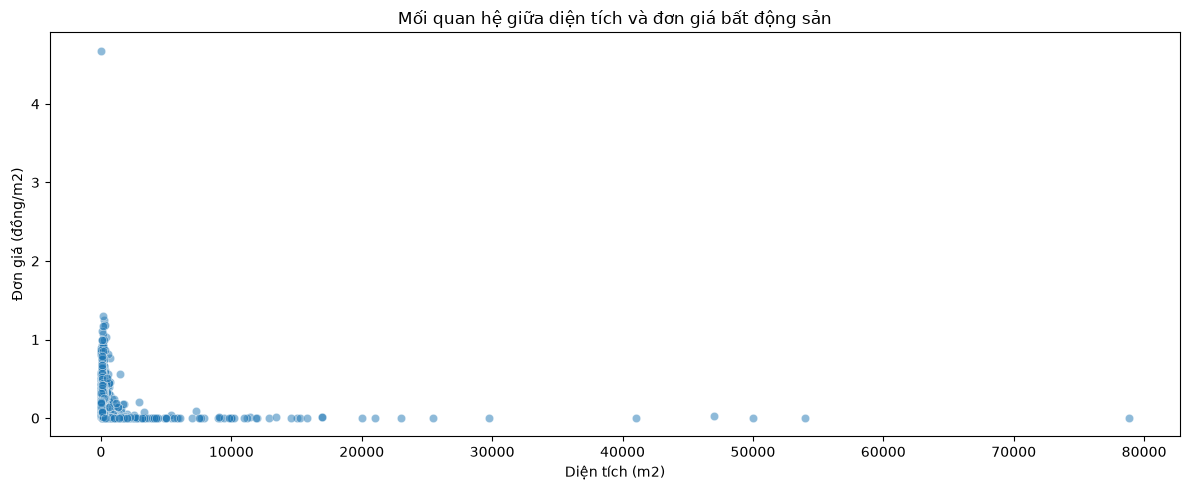

In [15]:
plt.figure(figsize=(12, 5))

sns.scatterplot(
    data=df_price,
    x="area",
    y="price_per_m2",
    alpha=0.5
)

plt.xlabel("Diện tích (m2)")
plt.ylabel("Đơn giá (đồng/m2)")
plt.title("Mối quan hệ giữa diện tích và đơn giá bất động sản")
plt.tight_layout()
plt.show()

Một điểm đáng lưu ý là **Giá trên mỗi mét vuông** càng cao thì **Diện tích** lại có phần thấp hơn

Dù đã lọc bỏ 5% giá cao nhất, biểu đồ vẫn lộ ra vài điểm bất thường: có tin diện tích tới ~50.000 m² và một điểm đơn giá/m² đột biến ~4.6 tỷ/m² — gần như chắc chắn là lỗi nhập liệu chứ không phải giá trị thực. Nên lọc thêm theo area và price_per_m2 (không chỉ price) khi phân tích đa biến để tránh các điểm này làm méo biểu đồ.

# Phân tích Địa lý và Thị trường

In [16]:
# 1. Tỉnh/thành phố dẫn đầu số lượng tin đăng và mức giá trung bình/trung vị
province_stats = df.groupby('province_name')['price'].agg(
    count='count',
    mean_price='mean',
    median_price='median'
).sort_values(by='count', ascending=False)
print("--- Thống kê theo Tỉnh/Thành phố ---")
print(province_stats.head(10))

--- Thống kê theo Tỉnh/Thành phố ---
                   count    mean_price  median_price
province_name                                       
Hồ Chí Minh         3476  1.647904e+10  7.600000e+09
Hà Nội              3103  1.560422e+10  9.600000e+09
Đà Nẵng              526  1.686001e+10  7.990000e+09
Bình Dương           380  6.119108e+09  2.900000e+09
Khánh Hòa            267  8.569119e+09  4.450000e+09
Hải Phòng            203  6.674642e+09  4.000000e+09
Hưng Yên             169  9.771509e+09  6.450000e+09
Đồng Nai             135  7.217036e+09  2.300000e+09
Bà Rịa - Vũng Tàu    127  1.040521e+10  3.550000e+09
Long An              118  4.122917e+09  1.895000e+09


So sáng trung vị và trung bình:
So sánh tương quan giữa Hà Nội và TP.HCM

- **Hà Nội**: Có giá trung vị cao hơn TP.HCM (9,6 tỷ so với 7,6 tỷ), chứng minh rằng mặt bằng giá nhà đất phổ biến tại các quận huyện của Thủ đô đang nhỉnh hơn. Tuy nhiên, giá trung bình của Hà Nội là 15,6 tỷ, thấp hơn một chút so với mức 16,47 tỷ của TP.HCM.

- **Hồ Chí Minh**: Dẫn đầu về quy mô thanh khoản với 3.476 tin đăng. Khoảng cách lớn giữa giá trung bình (16,47 tỷ) và trung vị (7,6 tỷ) phản ánh sự phân hóa sâu sắc giữa phân khúc nhà phố trung tâm/căn hộ cao cấp đắt đỏ và phân khúc nhà trong hẻm/vùng ven.

Sự bất đối xứng tại các thị trường trọng điểm và vùng ven

- **Đà Nẵng**: Ghi nhận mức giá trung bình cao nhất cả nước (16,86 tỷ), trong khi giá trung vị chỉ ở mức 7,99 tỷ. Điều này cho thấy thị trường Đà Nẵng chịu ảnh hưởng mạnh bởi các dự án bất động sản nghỉ dưỡng, ven biển phân khúc cao cấp kéo mức bình quân lên rất cao dù lượng tin đăng ít hơn (526 tin).

- **Bà Rịa - Vũng Tàu & Hưng Yên**: Là hai địa phương có độ lệch cực lớn. Điển hình như Bà Rịa - Vũng Tàu có giá trung bình lên tới 10,4 tỷ nhưng giá trung vị chỉ đạt 3,55 tỷ, cho thấy thị trường này tồn tại các dự án đất nền hoặc biệt thự nghỉ dưỡng quy mô lớn làm biến động mạnh giá trị trung bình.

- **Long An, Đồng Nai, Bình Dương**: Là các tỉnh vệ tinh có giá trung vị thấp nhất trong nhóm (dao động từ 1,89 tỷ đến 2,9 tỷ), phù hợp với đặc thù sản phẩm đất nền hoặc nhà liền thổ diện tích lớn có suất đầu tư vừa phải, đáp ứng nhu cầu thực của người có tài chính vừa phải. 

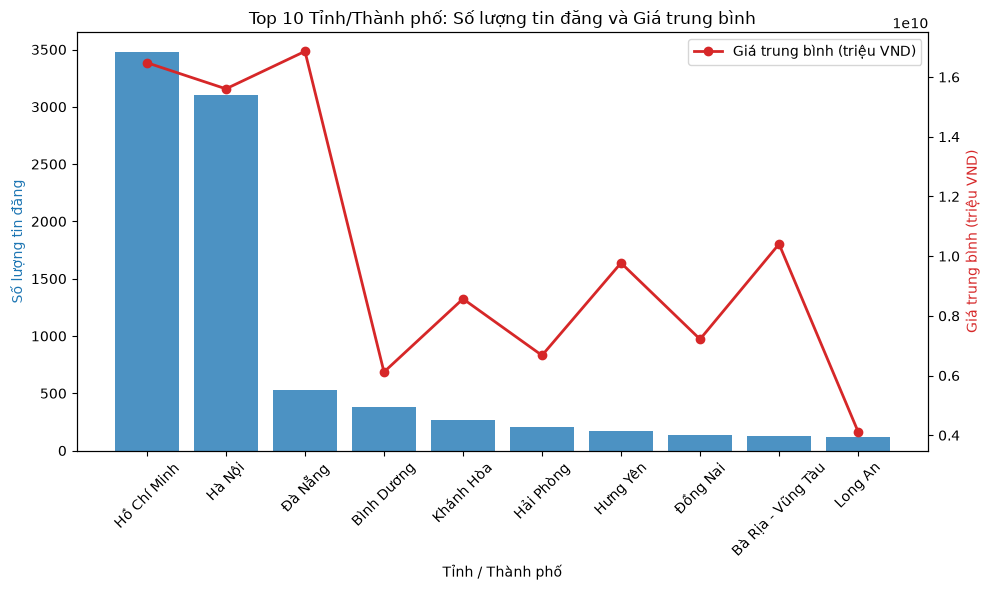

In [17]:
fig, ax1 = plt.subplots(figsize=(10, 6))
top_prov = province_stats.head(10).reset_index()

ax1.bar(top_prov['province_name'], top_prov['count'], color='tab:blue', alpha=0.8)
ax1.set_xlabel('Tỉnh / Thành phố')
ax1.set_xlabel('Tỉnh / Thành phố')
ax1.set_ylabel('Số lượng tin đăng', color='tab:blue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    top_prov['province_name'],
    top_prov['mean_price'],
    color='tab:red',
    marker='o',
    linewidth=2,
    label='Giá trung bình (triệu VND)',
)
ax2.set_ylabel('Giá trung bình (triệu VND)', color='tab:red')
handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles_1 + handles_2, labels_1 + labels_2, loc='upper right', frameon=True
)
plt.title('Top 10 Tỉnh/Thành phố: Số lượng tin đăng và Giá trung bình')
fig.tight_layout()
plt.show()
plt.close()

### Nhận xét:
- Mức giá trung bình và số lượng bài đăng cao nhất ở thành phố : Hà Nội và HCM -> Nhu cầu thực tế tại các thành phố về bất động sản là rất lớn.

- Ngoài ra có thể thấy Đà Nẵng có mức giá trung bình cao : Vì đây là thành phố nghỉ dưỡng, du lịch.. Vì vậy các bất động sản tại tập trung vào dạng bất động sản cao cấp dẫn đến mức giá bđs cao.



In [18]:
# 2. Giá bất động sản khác nhau giữa các quận/huyện (ví dụ tại Hà Nội và TP.HCM)
hn_hcm = df[df['province_name'].isin(['Hà Nội', 'Hồ Chí Minh','Đà Nẵng'])]
district_stats = hn_hcm.groupby(['province_name', 'district_name'])['price'].agg(
    count='count',
    median_price='median',
    iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
).reset_index().sort_values(by='median_price', ascending=False)
print("\n--- Biên độ giá các quận trọng điểm tại HN, TP.HCM, Đà Nẵng ---")
print(district_stats.head(10))




--- Biên độ giá các quận trọng điểm tại HN, TP.HCM, Đà Nẵng ---
   province_name district_name  count  median_price           iqr
30   Hồ Chí Minh             1    125  2.940000e+10  5.280000e+10
8         Hà Nội     Hoàn Kiếm     24  2.665000e+10  6.945000e+10
36   Hồ Chí Minh             5     31  1.750000e+10  2.295500e+10
34   Hồ Chí Minh             3     86  1.547500e+10  3.040000e+10
25        Hà Nội        Tây Hồ    148  1.500000e+10  1.832500e+10
1         Hà Nội       Ba Đình    114  1.400000e+10  1.455000e+10
28        Hà Nội       Đống Đa    248  1.370000e+10  1.250000e+10
57       Đà Nẵng       Sơn Trà    134  1.325000e+10  1.695000e+10
4         Hà Nội      Cầu Giấy    286  1.317500e+10  1.515000e+10
22        Hà Nội    Thanh Xuân    224  1.170000e+10  1.070000e+10


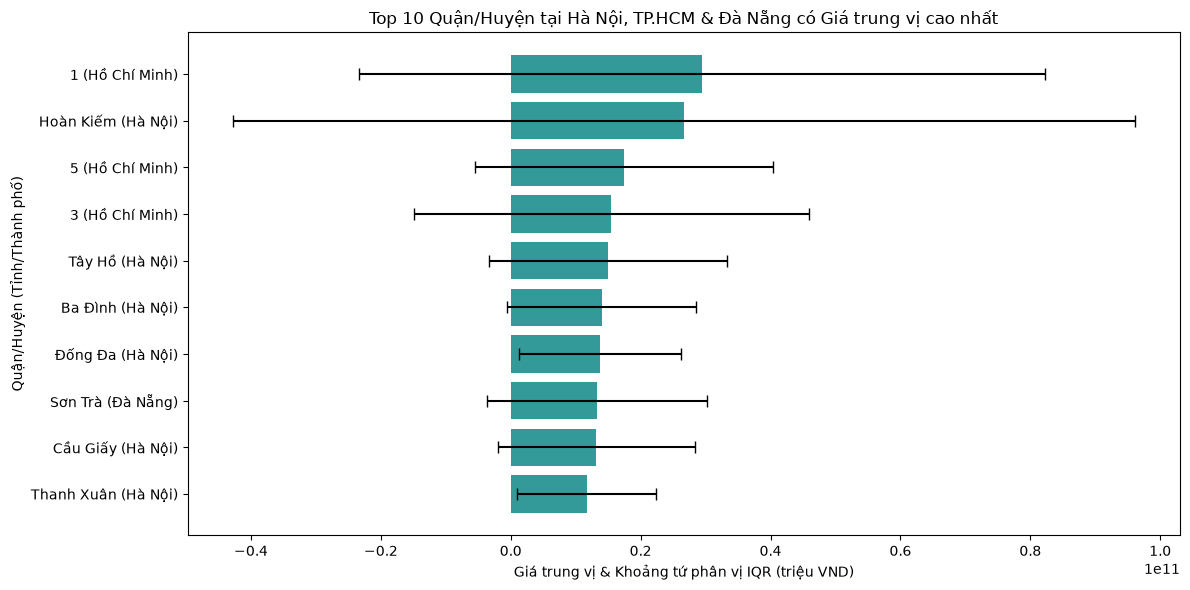

In [19]:
# Lọc dữ liệu cho top 3 có giá tb bds cao nhất Hà Nội, TP.HCM và Đà Nẵng 
hn_hcm_dn = df[df['province_name'].isin(['Hà Nội', 'Hồ Chí Minh', 'Đà Nẵng'])]
district_stats = (
    hn_hcm_dn.groupby(['province_name', 'district_name'])['price']
    .agg(
        count='count',
        median_price='median',
        iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
    )
    .reset_index()
    .sort_values(by='median_price', ascending=False)
)

plt.figure(figsize=(12, 6))
top_dist = district_stats.head(10)

plt.barh(
    top_dist['district_name'] + ' (' + top_dist['province_name'] + ')',
    top_dist['median_price'],
    xerr=top_dist['iqr'],
    color='teal',
    alpha=0.8,
    capsize=4,
)

plt.xlabel('Giá trung vị & Khoảng tứ phân vị IQR (triệu VND)')
plt.ylabel('Quận/Huyện (Tỉnh/Thành phố)')
plt.title(
    'Top 10 Quận/Huyện tại Hà Nội, TP.HCM & Đà Nẵng có Giá trung vị cao nhất'
)
plt.gca().invert_yaxis()
plt.tight_layout()
# plt.savefig('chart_district_top10.png', dpi=300)
plt.show()
plt.close()

- Sự thống trị của các lõi đô thị trung tâm (CBD): Top 10 khu vực dẫn đầu đều thuộc các quận trung tâm lịch sử và kinh tế trọng điểm của TP.HCM (Quận 1, Quận 3, Quận 5) và Hà Nội (Hoàn Kiếm, Tây Hồ, Ba Đình, Đống Đa, Cầu Giấy, Thanh Xuân). Đây là nơi tập trung các hoạt động thương mại, hành chính và có nguồn cung bất động sản khan hiếm.

- Đại diện của Đà Nẵng: Quận Sơn Trà góp mặt trong nhóm dẫn đầu, phản ánh sức hút mạnh mẽ của phân khúc bất động sản ven biển, nghỉ dưỡng và đô thị du lịch cao cấp tại Đà Nẵng có mặt bằng giá sánh ngang với các quận nội đô lớn.

- Biên độ phân hóa giá cực lớn (IQR): Thanh sai số (khoảng tứ phân vị - IQR) tại các vị trí đầu bảng như Hoàn Kiếm và Quận 1 rất rộng (vươn tới gần 100 tỷ VND). Điều này chỉ ra thị trường tại đây có sự phân hóa sâu sắc: đان xen giữa các tài sản giá trị siêu cao (nhà mặt phố cổ, biệt thự lớn) và các loại hình nhà trong ngõ nhỏ với mức giá dễ tiếp cận hơn.

- Đặc điểm phân phối dữ liệu: Do sử dụng thanh sai số đối xứng (xerr), phần cận dưới của một số quận kéo dài sang miền giá trị thấp, minh chứng cho thấy dữ liệu giá bất động sản tại khu vực trung tâm có độ lệch phải rất cao, với một nhóm nhỏ bất động sản giá trị khổng lồ kéo biên độ biến động mở rộng sang phía bên phải.

In [20]:
# KIỂM ĐỊNH THỐNG KÊ: SO SÁNH GIÁ HÀ NỘI vs TP.HCM (t-test)
hn_price = df[(df['province_name'] == 'Hà Nội')]['price'].dropna()
hcm_price = df[(df['province_name'] == 'Hồ Chí Minh')]['price'].dropna()
 
# Dùng log để giảm ảnh hưởng của outlier/lệch phân phối trước khi kiểm định
t_stat, p_value = stats.ttest_ind(
    np.log1p(hn_price), np.log1p(hcm_price), equal_var=False
)
print(f"--- T-test: log(price) Hà Nội vs TP.HCM ---")
print(f"t-statistic = {t_stat:.3f}, p-value = {p_value:.5f}")
if p_value < 0.05:
    print("=> Có sự khác biệt có ý nghĩa thống kê về giá giữa Hà Nội và TP.HCM.")
else:
    print("=> Chưa đủ bằng chứng thống kê cho thấy giá 2 thành phố khác nhau.")

--- T-test: log(price) Hà Nội vs TP.HCM ---
t-statistic = 7.678, p-value = 0.00000
=> Có sự khác biệt có ý nghĩa thống kê về giá giữa Hà Nội và TP.HCM.


In [21]:
# 3. Ảnh hưởng của vị trí nhà (có tên đường / mặt tiền) đến giá
df['has_street'] = df['street_name'].notnull()
print("\n--- So sánh giá theo việc có thông tin tên đường/mặt tiền ---")
print(df.groupby('has_street')['price'].agg(['count', 'median', 'mean']))


--- So sánh giá theo việc có thông tin tên đường/mặt tiền ---
            count        median          mean
has_street                                   
False        3554  5.980000e+09  1.241706e+10
True         5673  8.100000e+09  1.511648e+10



--- So sánh giá theo việc có thông tin tên đường/mặt tiền ---
   has_street  count        median          mean                    label
0       False   3554  5.980000e+09  1.241706e+10     Không có / Trong ngõ
1        True   5673  8.100000e+09  1.511648e+10  Có tên đường / Mặt tiền


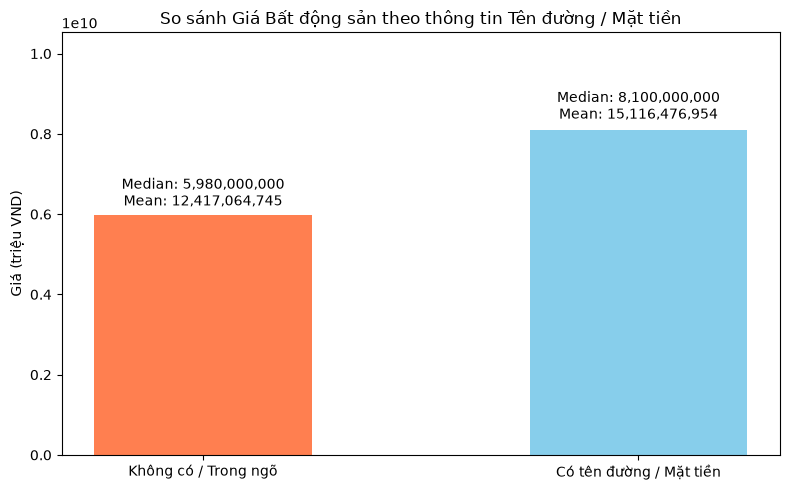

In [22]:
# Chuẩn bị dữ liệu cho mục 3
df['has_street'] = df['street_name'].notnull()
street_stats = (
    df.groupby('has_street')['price']
    .agg(['count', 'median', 'mean'])
    .reset_index()
)
street_stats['label'] = street_stats['has_street'].map(
    {True: 'Có tên đường / Mặt tiền', False: 'Không có / Trong ngõ'}
)

print('\n--- So sánh giá theo việc có thông tin tên đường/mặt tiền ---')
print(street_stats)

# Vẽ biểu đồ cột so sánh giá trung vị và trung bình
plt.figure(figsize=(8, 5))
bars = plt.bar(
    street_stats['label'],
    street_stats['median'],
    color=['coral', 'skyblue'],
    width=0.5,
)

# Hiển thị giá trị chi tiết trên từng cột
for i, row in street_stats.iterrows():
    plt.text(
        i,
        row['median'] + (row['median'] * 0.02),
        f"Median: {row['median']:,.0f}\nMean: {row['mean']:,.0f}",
        ha='center',
        va='bottom',
    )

plt.ylabel('Giá (triệu VND)')
plt.title('So sánh Giá Bất động sản theo thông tin Tên đường / Mặt tiền')
plt.ylim(0, street_stats['median'].max() * 1.3)
plt.tight_layout()
plt.show()
plt.close()

Lợi thế giá trị của mặt tiền đường: Bất động sản có thông tin tên đường hoặc mặt tiền sở hữu mặt bằng giá cao hơn rõ rệt so với nhóm trong ngõ hẻm. Cụ thể, giá trung vị (Median) tăng từ 5,98 tỷ VND lên 8,10 tỷ VND (tăng hơn 35%), minh chứng cho thấy lợi thế thương mại và khả năng tiếp cận giao thông trực tiếp tác động mạnh mẽ đến định giá tài sản.

Mức độ phân hóa và độ lệch phải (Skewness): Ở cả hai nhóm, giá trung bình (Mean) đều cao gấp đôi so với giá trung vị (Median) (ví dụ nhóm mặt tiền có trung vị 8,10 tỷ nhưng trung bình lên tới 15,12 tỷ). Điều này cho thấy dữ liệu có độ lệch phải rất lớn do tồn tại một nhóm nhỏ bất động sản giá trị siêu cao (như nhà mặt phố lớn, diện tích rộng) kéo mức bình quân lên cao.

Đặc điểm giao dịch thực tế: Giá trung vị ở mức ~5,98 tỷ đến ~8,10 tỷ phản ánh sát hơn khả năng chi trả của đa số người mua trên thị trường phổ thông, trong khi khoảng cách lớn với giá trị trung bình cảnh báo thị trường có sự góp mặt của các tài sản phân khúc cao cấp chiếm tỷ trọng giá trị lớn.

In [23]:
# 4. Ảnh hưởng của hướng nhà đến giá
direction_stats = df.groupby('house_direction')['price'].agg(['count', 'median', 'mean']).sort_values(by='median', ascending=False)
print("\n--- Giá bất động sản theo Hướng nhà ---")
print(direction_stats)


--- Giá bất động sản theo Hướng nhà ---
                 count        median          mean
house_direction                                   
Đông Nam           380  7.485000e+09  1.572883e+10
Đông - Nam         267  6.900000e+09  1.361498e+10
Tây - Nam          152  6.879550e+09  1.216085e+10
Đông Bắc           243  6.670000e+09  1.266223e+10
Tây Nam            225  6.600000e+09  1.316320e+10
Tây - Bắc          213  6.500000e+09  1.012126e+10
Tây Bắc            225  6.280000e+09  1.231698e+10
Đông - Bắc         174  6.200000e+09  1.153404e+10
Đông               303  6.000000e+09  1.290717e+10
Nam                296  5.925000e+09  1.044024e+10
Bắc                219  5.800000e+09  1.169662e+10
Tây                153  5.750000e+09  9.324688e+09



--- Giá bất động sản theo Hướng nhà ---
   house_direction  count        median          mean
0              Tây    153  5.750000e+09  9.324688e+09
1              Bắc    219  5.800000e+09  1.169662e+10
2              Nam    296  5.925000e+09  1.044024e+10
3             Đông    303  6.000000e+09  1.290717e+10
4       Đông - Bắc    174  6.200000e+09  1.153404e+10
5          Tây Bắc    225  6.280000e+09  1.231698e+10
6        Tây - Bắc    213  6.500000e+09  1.012126e+10
7          Tây Nam    225  6.600000e+09  1.316320e+10
8         Đông Bắc    243  6.670000e+09  1.266223e+10
9        Tây - Nam    152  6.879550e+09  1.216085e+10
10      Đông - Nam    267  6.900000e+09  1.361498e+10
11        Đông Nam    380  7.485000e+09  1.572883e+10


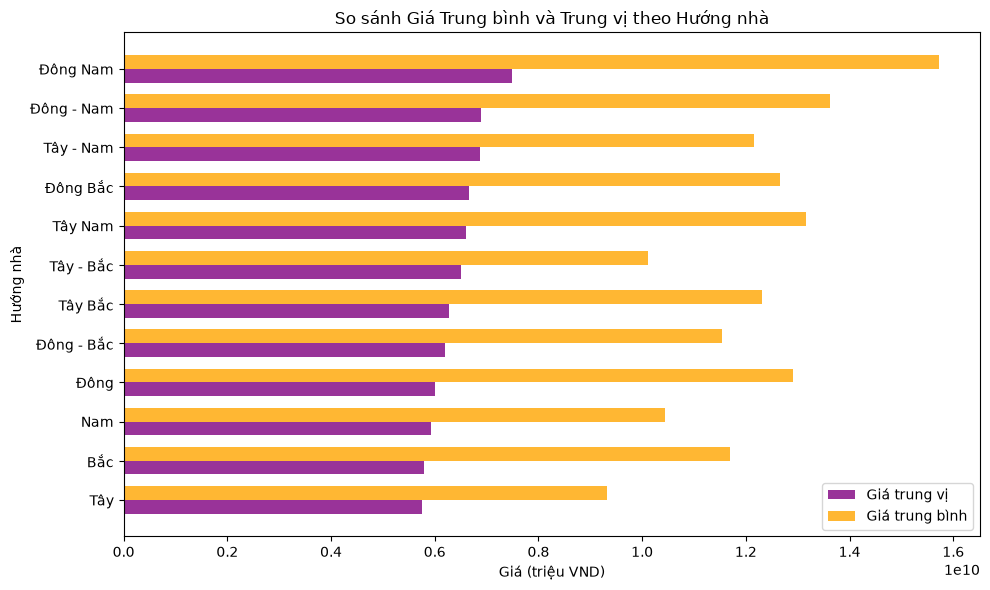

In [24]:
direction_stats = (
    df.groupby('house_direction')['price']
    .agg(['count', 'median', 'mean'])
    .sort_values(by='median', ascending=True)
    .reset_index()
)

print('\n--- Giá bất động sản theo Hướng nhà ---')
print(direction_stats)

# Vẽ biểu đồ cột ngang so sánh Giá trung bình và Giá trung vị theo hướng nhà
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(direction_stats))
width = 0.35

plt.barh(
    y_pos - width / 2,
    direction_stats['median'],
    width,
    label='Giá trung vị',
    color='purple',
    alpha=0.8,
)
plt.barh(
    y_pos + width / 2,
    direction_stats['mean'],
    width,
    label='Giá trung bình',
    color='orange',
    alpha=0.8,
)

plt.yticks(y_pos, direction_stats['house_direction'])
plt.xlabel('Giá (triệu VND)')
plt.ylabel('Hướng nhà')
plt.title('So sánh Giá Trung bình và Trung vị theo Hướng nhà')
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

Lợi thế về hướng nhà: Các bất động sản có hướng nnhà thuộc các hướng (ĐN, TB DB) là các hướng nhà lí tưởng đảm có lợi thế cạnh tranh cao về giá

Phân hoá trung vị (màu tràm): hướng (ĐN, TB DB) tập trung các bất động sản có quy mô lớn và giá trị quy hoạch cao hơn.

Phân hoá trung bình: Hướng Đông & ĐN có giá trị trung bình bất động sản cao -> thường tập trung các dự án có giá trị cao.

Độ lệch phân phối giá (Mean vs. Median): Giá trung bình (màu cam) luôn cao hơn rõ rệt so với giá trung vị (màu tím) ở tất cả các loại hướng nhà. Điều này tiếp tục củng cố đặc trưng phân phối lệch phải của dữ liệu bất động sản tổng thể, chịu ảnh hưởng bởi một nhóm nhỏ tài sản giá trị cao kéo mức bình quân lên.

In [25]:
# KIỂM ĐỊNH ANOVA: GIÁ THEO HƯỚNG NHÀ (house_direction)
dir_groups = [
    np.log1p(g['price'].dropna())
    for _, g in df.groupby('house_direction')
    if g['price'].notna().sum() > 1
]
f_stat_dir, p_value_dir = stats.f_oneway(*dir_groups)
print(f"--- ANOVA: log(price) theo house_direction ---")
print(f"F-statistic = {f_stat_dir:.3f}, p-value = {p_value_dir:.5f}")
if p_value_dir < 0.05:
    print("=> Hướng nhà có ảnh hưởng có ý nghĩa thống kê đến giá.")
else:
    print("=> Chưa đủ bằng chứng cho thấy hướng nhà ảnh hưởng đến giá.")

--- ANOVA: log(price) theo house_direction ---
F-statistic = 1.781, p-value = 0.05178
=> Chưa đủ bằng chứng cho thấy hướng nhà ảnh hưởng đến giá.


# Chất lượng Dữ liệu và Xu hướng Thời gian

In [26]:
missing_analysis = df.groupby('property_type_name')[['project_name', 'house_depth', 'balcony_direction']].apply(
    lambda x: (x.isnull().mean() * 100).round(2)
)
print("--- Tỷ lệ khuyết dữ liệu (%) theo Loại hình BĐS ---")
print(missing_analysis)

# 2. Chuyển đổi định dạng thời gian và phân tích xu hướng xuất bản tin đăng theo tháng/quý
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')
df['month'] = df['published_at'].dt.month
df['quarter'] = df['published_at'].dt.quarter

monthly_trend = df.groupby('month').agg(
    listing_count=('price', 'count'),
    median_price=('price', 'median')
).reset_index()

print("\n--- Xu hướng lượng tin đăng và giá theo Tháng ---")
print(monthly_trend)

--- Tỷ lệ khuyết dữ liệu (%) theo Loại hình BĐS ---
                      project_name  house_depth  balcony_direction
property_type_name                                                
Biệt thự/Nhà liền kề         30.33        99.21              75.63
Căn hộ chung cư              11.88        99.86              57.94
Nhà                          98.12        97.62              90.60
Shophouse                     5.88       100.00              68.24
Đất                          94.29        94.04              99.92

--- Xu hướng lượng tin đăng và giá theo Tháng ---
   month  listing_count  median_price
0    6.0            934  7.500000e+09
1    7.0           1370  7.000000e+09
2    8.0           1289  7.200000e+09
3    9.0           1204  7.525000e+09
4   10.0           1463  7.500000e+09
5   11.0           1452  7.360000e+09
6   12.0           1501  7.500000e+09


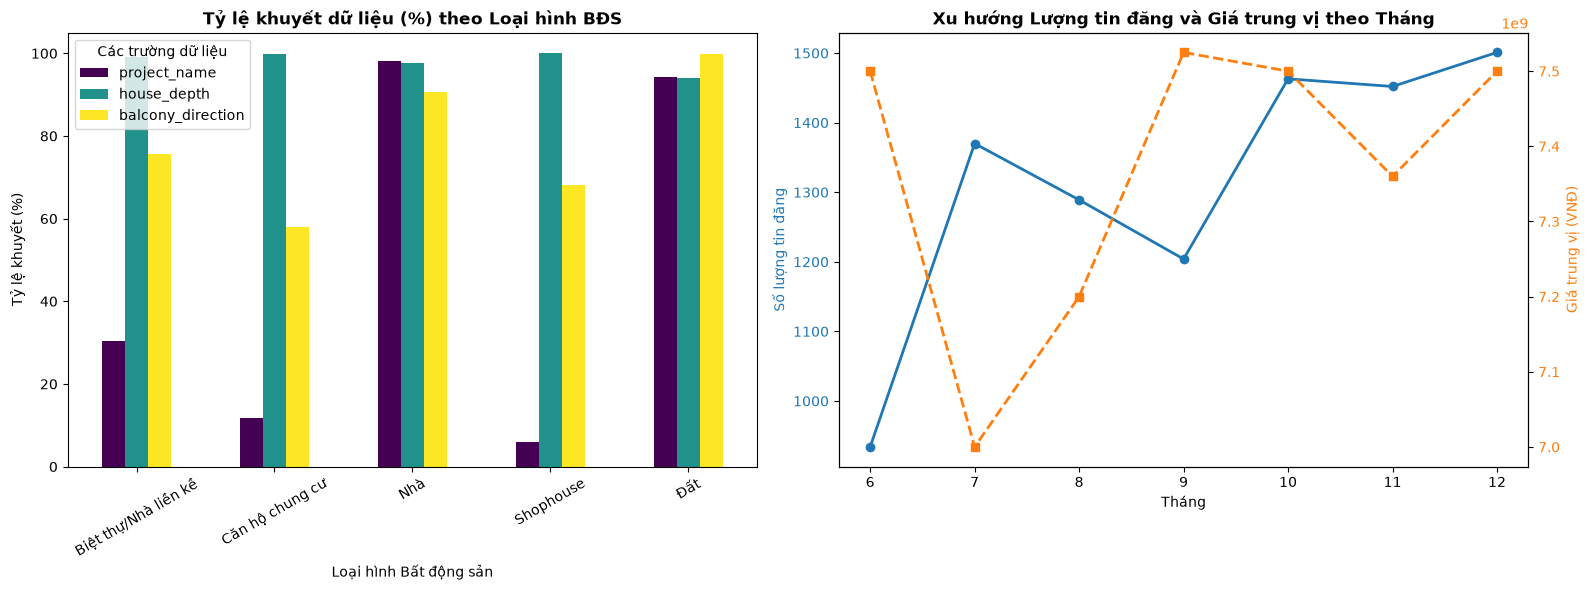

In [27]:
# Khởi tạo khung chứa 2 biểu đồ con (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Tỷ lệ khuyết dữ liệu (%) theo Loại hình BĐS
missing_analysis.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Tỷ lệ khuyết dữ liệu (%) theo Loại hình BĐS', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loại hình Bất động sản')
axes[0].set_ylabel('Tỷ lệ khuyết (%)')
axes[0].legend(title='Các trường dữ liệu')
axes[0].tick_params(axis='x', rotation=30)

# Biểu đồ 2: Xu hướng lượng tin đăng và giá trung vị theo tháng (Trục tung kép - Dual Axis)
ax1 = axes[1]
color = 'tab:blue'
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Số lượng tin đăng', color=color)
ax1.plot(monthly_trend['month'], monthly_trend['listing_count'], color=color, marker='o', linewidth=2, label='Số lượng tin')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Giá trung vị (VNĐ)', color=color)
ax2.plot(monthly_trend['month'], monthly_trend['median_price'], color=color, marker='s', linestyle='--', linewidth=2, label='Giá trung vị')
ax2.tick_params(axis='y', labelcolor=color)

axes[1].set_title('Xu hướng Lượng tin đăng và Giá trung vị theo Tháng', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Đặc điểm Tỷ lệ khuyết dữ liệu (Biểu đồ trái)**

- Chiều sâu nhà (house_depth): Ghi nhận tỷ lệ khuyết dữ liệu nghiêm trọng nhất, xấp xỉ 100% ở hầu hết các loại hình bất động sản, phản ánh đây là trường thông tin hầu như không được người đăng tin cung cấp.

- Tên dự án (project_name): Thiếu hụt trầm trọng ở phân khúc Nhà (~98%) và Đất (~94%) do đặc thù là nhà riêng thổ cư hoặc đất tự do không thuộc dự án quy hoạch; ngược lại, mức khuyết thấp ở Shophouse (~6%) và Căn hộ (~12%).

- Hướng ban công (balcony_direction): Bị khuyết gần như tuyệt đối ở phân khúc Đất (~100%) và chiếm tỷ lệ rất cao ở Nhà (~90%), trong khi phân khúc Căn hộ có mức độ hoàn thiện tốt hơn (chỉ khuyết khoảng 58%).

**Xu hướng Lượng tin đăng và Biến động Giá theo Tháng (Biểu đồ phải)**

- Biến động lượng tin đăng (Đường xanh): Thị trường thể hiện tính mùa vụ rõ rệt khi nguồn cung tăng vọt từ tháng 6 lên đỉnh điểm vào tháng 7 (~1,370 tin), chững lại nhẹ vào tháng 9, sau đó tiếp tục bứt phá mạnh mẽ trong quý IV và đạt đỉnh cao nhất vào tháng 12 (~1,500 tin).

- Biến động giá trung vị (Đường cam đứt đoạn): Dao động ổn định trong biên độ hẹp từ 7.0 đến 7.52 tỷ VNĐ trong suốt 7 tháng khảo sát.

- Điểm nghịch lý tháng 7: Tháng 7 ghi nhận lượng tin đăng tăng mạnh nhưng giá trung vị lại chạm đáy thấp nhất (~7.0 tỷ VNĐ), cho thấy giai đoạn này thị trường xuất hiện nhiều sản phẩm phân khúc giá mềm hoặc đất nền nhỏ lẻ để thu hút người mua.

- Giai đoạn cuối năm: Từ tháng 10 đến tháng 12, thị trường duy trì sự đồng pha khi cả lượng tin đăng lẫn giá trung vị đều giữ ở mức cao ổn định (xấp xỉ 7.5 tỷ VNĐ), thể hiện sức mua và hoạt động giao dịch sôi động dịp cuối năm.

In [28]:
# KIỂM ĐỊNH ANOVA: GIÁ THEO LOẠI HÌNH BẤT ĐỘNG SẢN
groups = [
    np.log1p(g['price'].dropna())
    for _, g in df.groupby('property_type_name')
    if g['price'].notna().sum() > 1
]
f_stat, p_value_anova = stats.f_oneway(*groups)
print(f"--- ANOVA: log(price) theo property_type_name ---")
print(f"F-statistic = {f_stat:.3f}, p-value = {p_value_anova:.5f}")
if p_value_anova < 0.05:
    print("=> Có sự khác biệt có ý nghĩa thống kê về giá giữa các loại hình BĐS.")
else:
    print("=> Chưa đủ bằng chứng cho thấy giá khác nhau giữa các loại hình BĐS.")

--- ANOVA: log(price) theo property_type_name ---
F-statistic = 501.579, p-value = 0.00000
=> Có sự khác biệt có ý nghĩa thống kê về giá giữa các loại hình BĐS.


Kết quả t-test (t = 7.678, p < 0.001) khẳng định có ý nghĩa thống kê: mức giá giữa Hà Nội và TP.HCM thực sự khác nhau, củng cố cho nhận xét định tính ở phần so sánh trung vị/trung bình phía trên.

# Phân tích Đặc điểm Kiến trúc và Quy hoạch (Property Features)

-	Số lượng phòng ngủ (bedroom_count), phòng tắm (bathroom_count) hoặc số tầng (floor_count) tác động ra sao đến tổng giá trị tài sản?

In [29]:
# Số phòng ngủ tác động đến giá
bedroom_price = (
    df.groupby("bedroom_count")
    .agg(
        count=("price", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median")
    )
    .reset_index()
    .sort_values("bedroom_count")
)

display(bedroom_price)

,bedroom_count,count,mean_price,median_price
0,1.0,305,7.030316e+09,3.150000e+09
1,2.0,1455,5.589116e+09,4.200000e+09
2,3.0,1442,8.799105e+09,6.900000e+09
3,4.0,1085,1.290270e+10,8.950000e+09
4,5.0,408,1.928069e+10,1.325000e+10
5,6.0,139,2.294327e+10,1.450000e+10
6,7.0,31,2.319000e+10,1.080000e+10
7,8.0,27,1.905889e+10,1.250000e+10
8,9.0,19,1.552889e+10,9.799000e+09
9,10.0,17,2.856512e+10,1.560000e+10


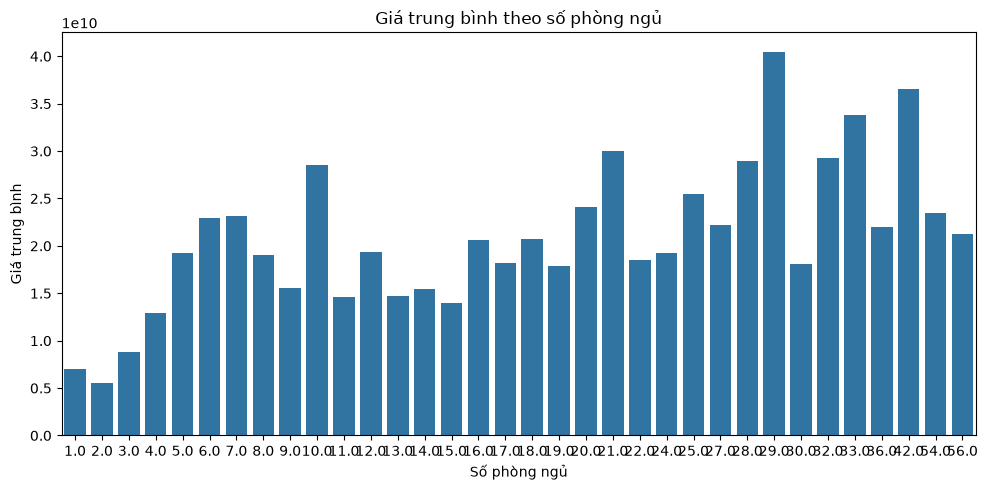

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=bedroom_price,
    x="bedroom_count",
    y="mean_price"
)

plt.title("Giá trung bình theo số phòng ngủ")
plt.xlabel("Số phòng ngủ")
plt.ylabel("Giá trung bình")

plt.tight_layout()
plt.show()

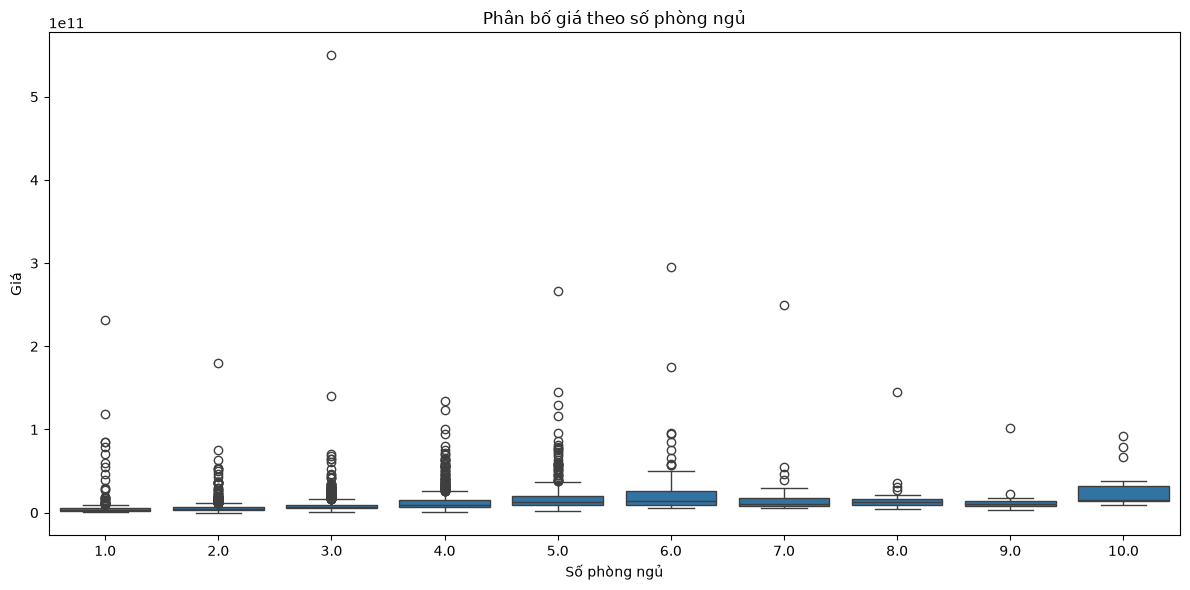

In [31]:
bedroom_plot = df[
    (df["bedroom_count"].notna()) &
    (df["bedroom_count"] <= 10)
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=bedroom_plot,
    x="bedroom_count",
    y="price"
)

plt.title("Phân bố giá theo số phòng ngủ")
plt.xlabel("Số phòng ngủ")
plt.ylabel("Giá")

plt.tight_layout()
plt.show()

từ 2 biểu đồ trên thì ta thấy được rõ là giá nhà đất tăng dần theo số lượng phòng ngủ, các bds có 1-3 phòng ngủ thường tập trung ở giá thấp trong khi nhóm bds từ 4 phòng ngủ trở lên có mức giá trung vị và độ phân tán cao hơn. tuy nhiên trong đoạn từ 3-7 phòng ngủ có 1 số giá trị chênh lệch rất lớn so  với dữ liệu. 
kết luận lại: giá trị của bất động sản có xu hướng giá tăng theo số phòng ngủ, nhưng mối quan hệ bị ảnh hưởng bởi các outlier và còn phụ thuộc vào nhiều yếu tố khác.

In [32]:
# Số phòng tắm và giá
bathroom_price = (
    df.groupby("bathroom_count")
    .agg(
        count=("price", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median")
    )
    .reset_index()
    .sort_values("bathroom_count")
)

display(bathroom_price)

,bathroom_count,count,mean_price,median_price
0,1.0,555,5.872125e+09,3.300000e+09
1,2.0,1813,6.659662e+09,5.250000e+09
2,3.0,720,1.016021e+10,7.070000e+09
3,4.0,809,1.381014e+10,8.800000e+09
4,5.0,519,1.658177e+10,1.095000e+10
5,6.0,97,1.995439e+10,1.480000e+10
6,7.0,51,2.136608e+10,1.290000e+10
7,8.0,28,2.048464e+10,1.195000e+10
8,9.0,10,1.755990e+10,1.535000e+10
9,10.0,13,2.550308e+10,1.390000e+10


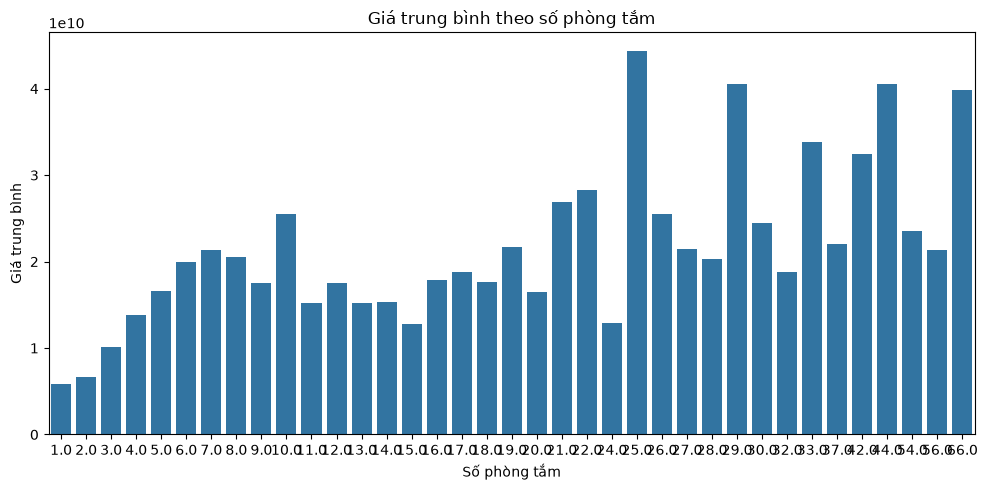

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=bathroom_price,
    x="bathroom_count",
    y="mean_price"
)

plt.title("Giá trung bình theo số phòng tắm")
plt.xlabel("Số phòng tắm")
plt.ylabel("Giá trung bình")

plt.tight_layout()
plt.show()

Cũng tương tự số phòng ngủ thì ta cũng thấy rõ được giá của bds có xu hướng tăng khi số lượng phòng tắm tăng lên

In [34]:
# Số tầng và giá
floor_price = (
    df.groupby("floor_count")
    .agg(
        count=("price", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median")
    )
    .reset_index()
    .sort_values("floor_count")
)

display(floor_price)

,floor_count,count,mean_price,median_price
0,1.0,121,1.177945e+10,5.150000e+09
1,2.0,347,9.941034e+09,5.950000e+09
2,3.0,443,1.473424e+10,7.800000e+09
3,4.0,545,1.758749e+10,1.000000e+10
4,5.0,484,1.461605e+10,1.050000e+10
5,6.0,170,1.969051e+10,1.455000e+10
6,7.0,98,2.332368e+10,1.930000e+10
7,8.0,26,3.709231e+10,2.860000e+10
8,9.0,14,4.507857e+10,3.865000e+10
9,10.0,7,8.198578e+10,6.700000e+10


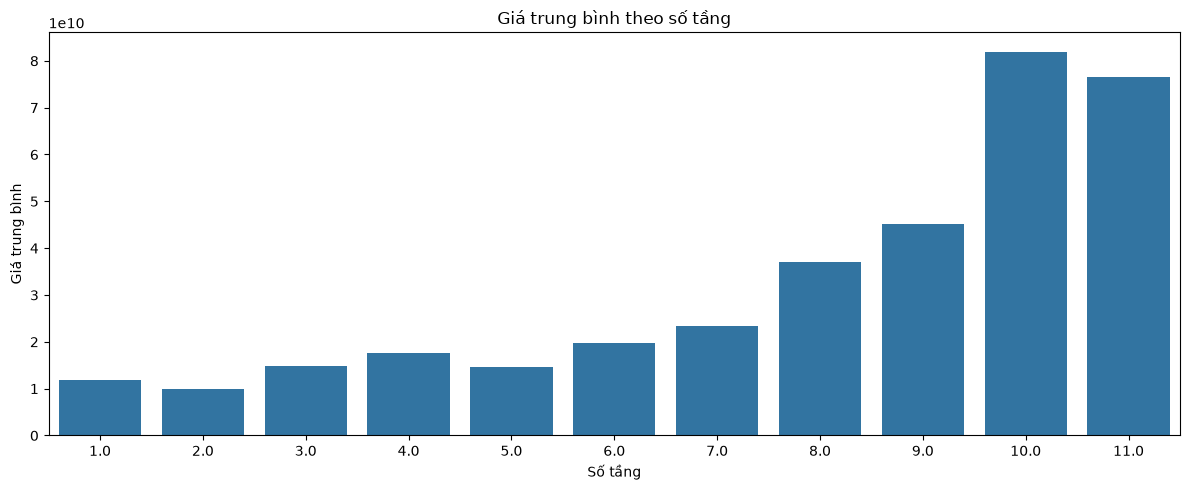

In [35]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=floor_price,
    x="floor_count",
    y="mean_price"
)

plt.title("Giá trung bình theo số tầng")
plt.xlabel("Số tầng")
plt.ylabel("Giá trung bình")

plt.tight_layout()
plt.show()

Kết luận: Ta thấy rõ được giá trị của bất động sản sẽ có xu hướng tăng dần khi mà số lượng phòng ngủ, số phòng tắm, tầng tăng lên

-	Các yếu tố như chiều rộng mặt tiền (frontage_width) và độ rộng đường trước nhà (road_width) làm thay đổi giá bán như thế nào?

Kết quả ANOVA cho p = 0.05178 — cao hơn (dù rất sát) ngưỡng ý nghĩa thống kê 0.05. Nói cách khác, chưa đủ bằng chứng chắc chắn để khẳng định hướng nhà ảnh hưởng đến giá ở độ tin cậy 95%. Nhận xét định tính ở phần trước nên diễn đạt thận trọng hơn (là "xu hướng nhẹ" thay vì khẳng định chắc chắn), một phần vì house_direction chỉ có dữ liệu ở ~30% tin đăng, cỡ mẫu khá nhỏ và không đồng đều giữa các nhóm hướng.

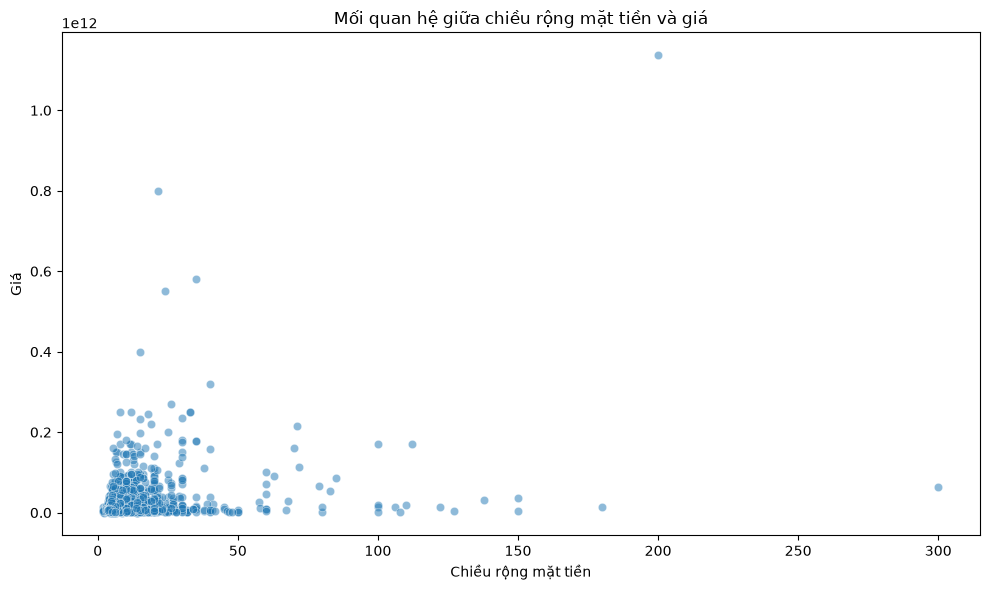

In [36]:
#frontage_width và giá
frontage_data = df[
    df["frontage_width"].notna() &
    df["price"].notna()
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=frontage_data,
    x="frontage_width",
    y="price",
    alpha=0.5
)

plt.title("Mối quan hệ giữa chiều rộng mặt tiền và giá")
plt.xlabel("Chiều rộng mặt tiền")
plt.ylabel("Giá")

plt.tight_layout()
plt.show()

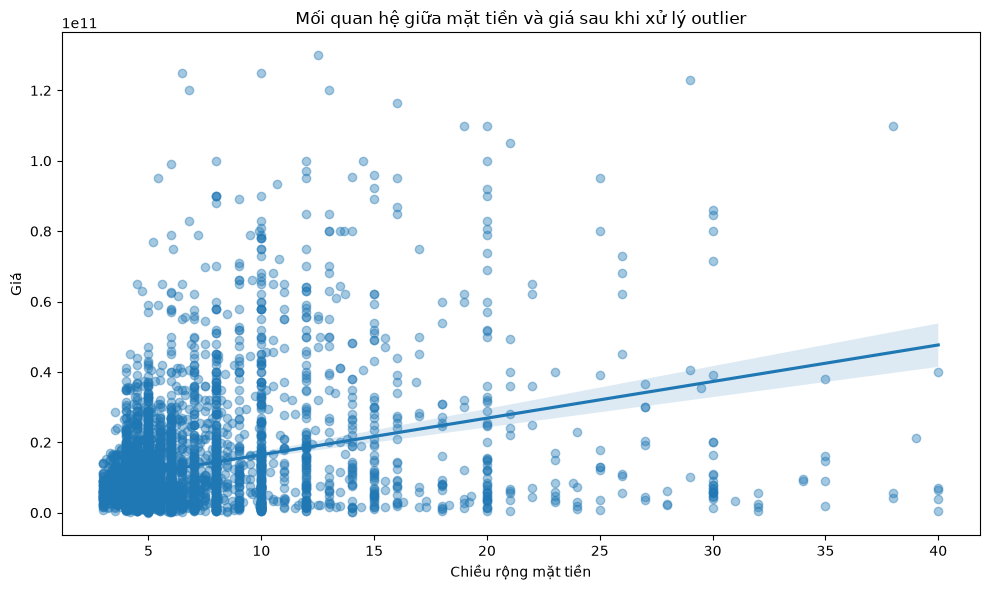

In [37]:
frontage_clean = frontage_data[
    (frontage_data["frontage_width"] >= frontage_data["frontage_width"].quantile(0.01)) &
    (frontage_data["frontage_width"] <= frontage_data["frontage_width"].quantile(0.99)) &
    (frontage_data["price"] <= frontage_data["price"].quantile(0.99))
]

plt.figure(figsize=(10, 6))

sns.regplot(
    data=frontage_clean,
    x="frontage_width",
    y="price",
    scatter_kws={"alpha": 0.4}
)

plt.title("Mối quan hệ giữa mặt tiền và giá sau khi xử lý outlier")
plt.xlabel("Chiều rộng mặt tiền")
plt.ylabel("Giá")

plt.tight_layout()
plt.show()

Sau khi xử lý outlier, chiều rộng mặt tiền có mối quan hệ thuận chiều với giá bất động sản. Tuy nhiên, mức độ phân tán của dữ liệu khá lớn, cho thấy chiều rộng mặt tiền chỉ giải thích một phần sự biến động của giá và còn nhiều yếu tố khác tác động đến giá bất động sản.

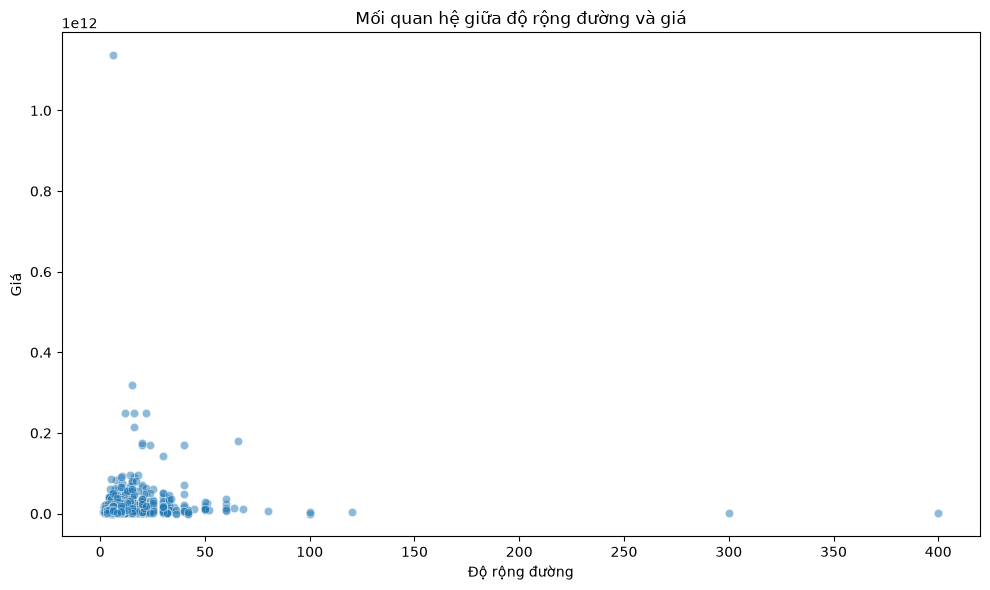

In [38]:
road_data = df[
    df["road_width"].notna() &
    df["price"].notna()
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=road_data,
    x="road_width",
    y="price",
    alpha=0.5
)

plt.title("Mối quan hệ giữa độ rộng đường và giá")
plt.xlabel("Độ rộng đường")
plt.ylabel("Giá")

plt.tight_layout()
plt.show()

với mối tương quan giữa độ rộng của đường với giá thì ko cho thấy rõ được sự ảnh hưởng của độ rộng đường ảnh hưởng đến giá, dữ liệu tập trung chủ yếu ở các đường có độ rộng bé 

-	Hướng nhà (house_direction) và hướng ban công (balcony_direction) có tạo ra sự chênh lệch đáng kể về giá trị giao dịch hay không?

In [39]:
direction_price = (
    df.groupby("house_direction")
    .agg(
        count=("price", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median")
    )
    .reset_index()
    .sort_values("mean_price", ascending=False)
)

display(direction_price)

,house_direction,count,mean_price,median_price
11,Đông Nam,380,1.572883e+10,7.485000e+09
9,Đông - Nam,267,1.361498e+10,6.900000e+09
6,Tây Nam,225,1.316320e+10,6.600000e+09
7,Đông,303,1.290717e+10,6.000000e+09
10,Đông Bắc,243,1.266223e+10,6.670000e+09
5,Tây Bắc,225,1.231698e+10,6.280000e+09
4,Tây - Nam,152,1.216085e+10,6.879550e+09
0,Bắc,219,1.169662e+10,5.800000e+09
8,Đông - Bắc,174,1.153404e+10,6.200000e+09
1,Nam,296,1.044024e+10,5.925000e+09


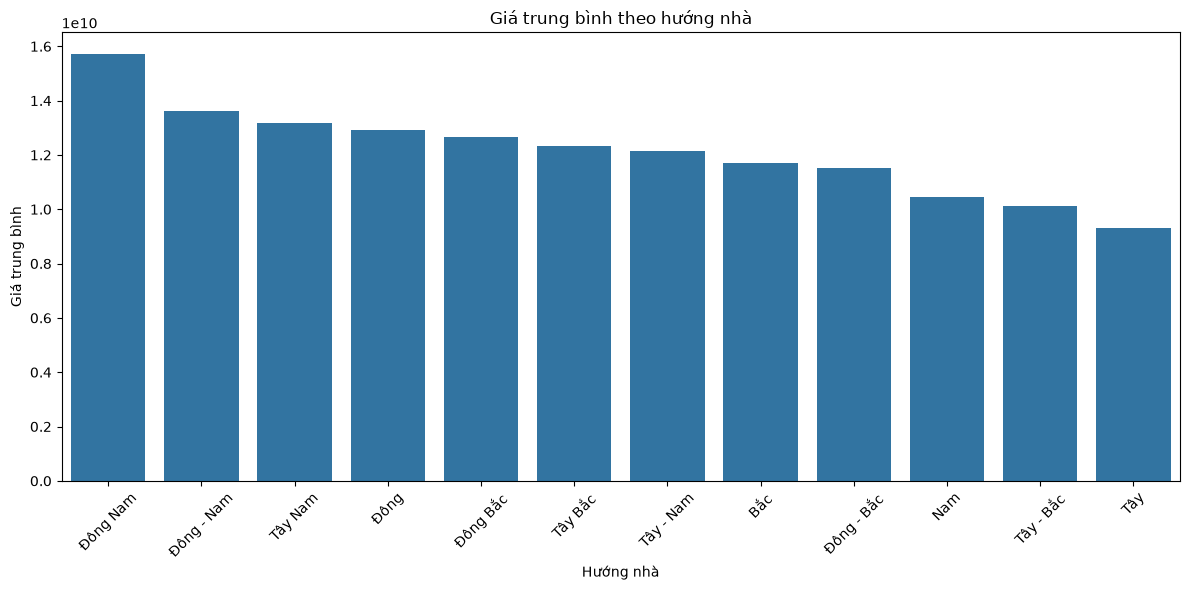

In [40]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=direction_price,
    x="house_direction",
    y="mean_price"
)

plt.title("Giá trung bình theo hướng nhà")
plt.xlabel("Hướng nhà")
plt.ylabel("Giá trung bình")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

F-statistic rất lớn (501.6) với p < 0.001 — khẳng định chắc chắn có sự khác biệt giá giữa các loại hình BĐS, đúng như quan sát trực quan (biệt thự/nhà liền kề có giá vượt trội so với chung cư).

# Phân tích Xu hướng Thời gian (Temporal Trends) 

-	Tần suất xuất bản tin đăng (published_at) phân bố theo thời gian (theo tháng, quý hoặc ngày trong tuần) như thế nào? (Hưng ơi t thấy phần này EDA xong nó chả có ích)

In [41]:
# Chuyển đổi published_at sang datetime
df["published_at"] = pd.to_datetime(
    df["published_at"],
    errors="coerce"
)

In [42]:
print(df["published_at"].min())
print(df["published_at"].max())

print("Số giá trị không chuyển đổi được:",
      df["published_at"].isna().sum())

2025-06-01 02:21:41.045000
2025-12-30 23:45:13.110000
Số giá trị không chuyển đổi được: 14


In [43]:
# tạo thêm các thuộc tính thời gian để dễ phân tích
df["published_year"] = df["published_at"].dt.year
df["published_month"] = df["published_at"].dt.month
df["published_quarter"] = df["published_at"].dt.quarter
df["published_dayofweek"] = df["published_at"].dt.day_name()

df["year_month"] = df["published_at"].dt.to_period("M")

-	Có sự dịch chuyển hoặc biến động rõ rệt nào về mức giá trung bình của các loại hình bất động sản qua các mốc thời gian đăng tin không? (phần này được hơn)

In [44]:
# Giá trung bình theo tháng
monthly_price = (
    df.groupby("year_month")
    .agg(
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        count=("price", "count")
    )
    .reset_index()
)

monthly_price["year_month"] = monthly_price[
    "year_month"
].astype(str)

display(monthly_price)

,year_month,mean_price,median_price,count
0,2025-06,1.526968e+10,7.500000e+09,934
1,2025-07,1.462772e+10,7.000000e+09,1370
2,2025-08,1.398540e+10,7.200000e+09,1289
3,2025-09,1.327589e+10,7.525000e+09,1204
4,2025-10,1.450117e+10,7.500000e+09,1463
5,2025-11,1.389397e+10,7.360000e+09,1452
6,2025-12,1.336134e+10,7.500000e+09,1501


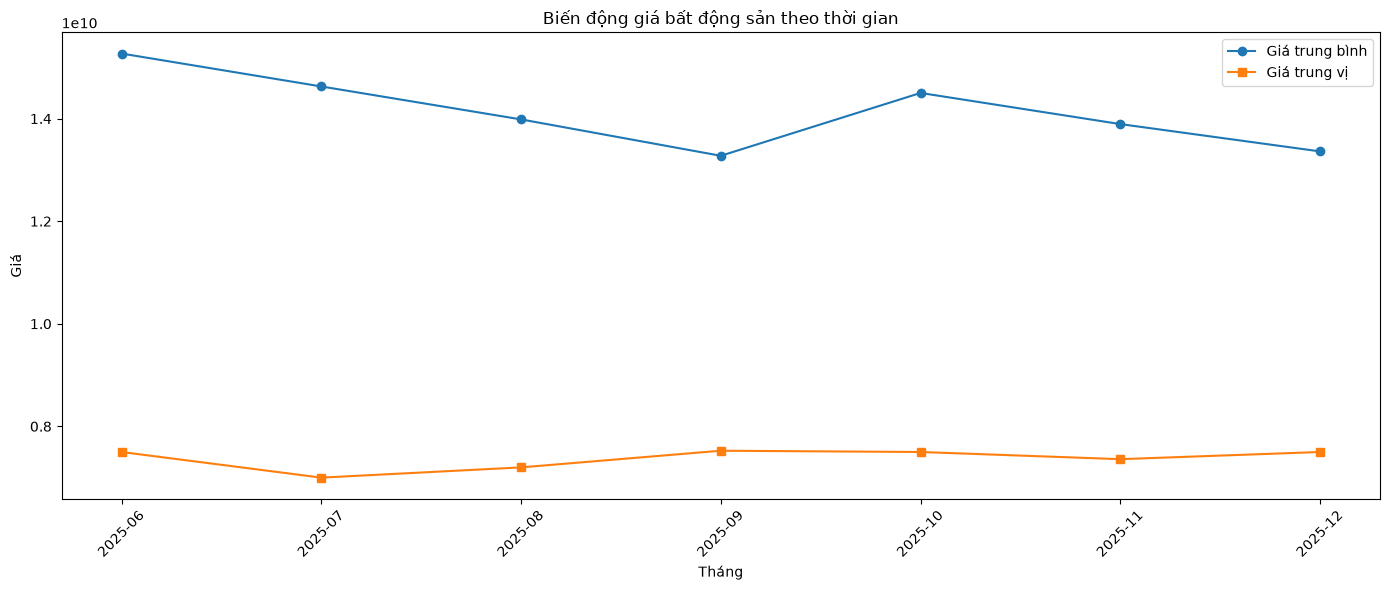

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_price["year_month"],
    monthly_price["mean_price"],
    marker="o",
    label="Giá trung bình"
)

plt.plot(
    monthly_price["year_month"],
    monthly_price["median_price"],
    marker="s",
    label="Giá trung vị"
)

plt.title("Biến động giá bất động sản theo thời gian")
plt.xlabel("Tháng")
plt.ylabel("Giá")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

Ta thấy được trong nữa năm 2025 thì giá trị của bất động sản có biến động kha khá và có xu hướng giảm dần khi về đoạn cuối năm

In [46]:
#Giá theo thời gian và loại hình bất động sản
top_property_types = (
    df["property_type_name"]
    .value_counts()
    .head(5)
    .index
)

df_top_types = df[
    df["property_type_name"].isin(top_property_types)
]

In [47]:
monthly_type_price = (
    df_top_types
    .groupby(["year_month", "property_type_name"])
    .agg(
        mean_price=("price", "mean"),
        median_price=("price", "median")
    )
    .reset_index()
)

monthly_type_price["year_month"] = (
    monthly_type_price["year_month"].astype(str)
)

display(monthly_type_price.head())

,year_month,property_type_name,mean_price,median_price
0,2025-06,Biệt thự/Nhà liền kề,2.798483e+10,1.905000e+10
1,2025-06,Căn hộ chung cư,6.200983e+09,4.400000e+09
2,2025-06,Nhà,1.789809e+10,9.250000e+09
3,2025-06,Shophouse,8.836111e+09,6.585000e+09
4,2025-06,Đất,1.450890e+10,4.790000e+09


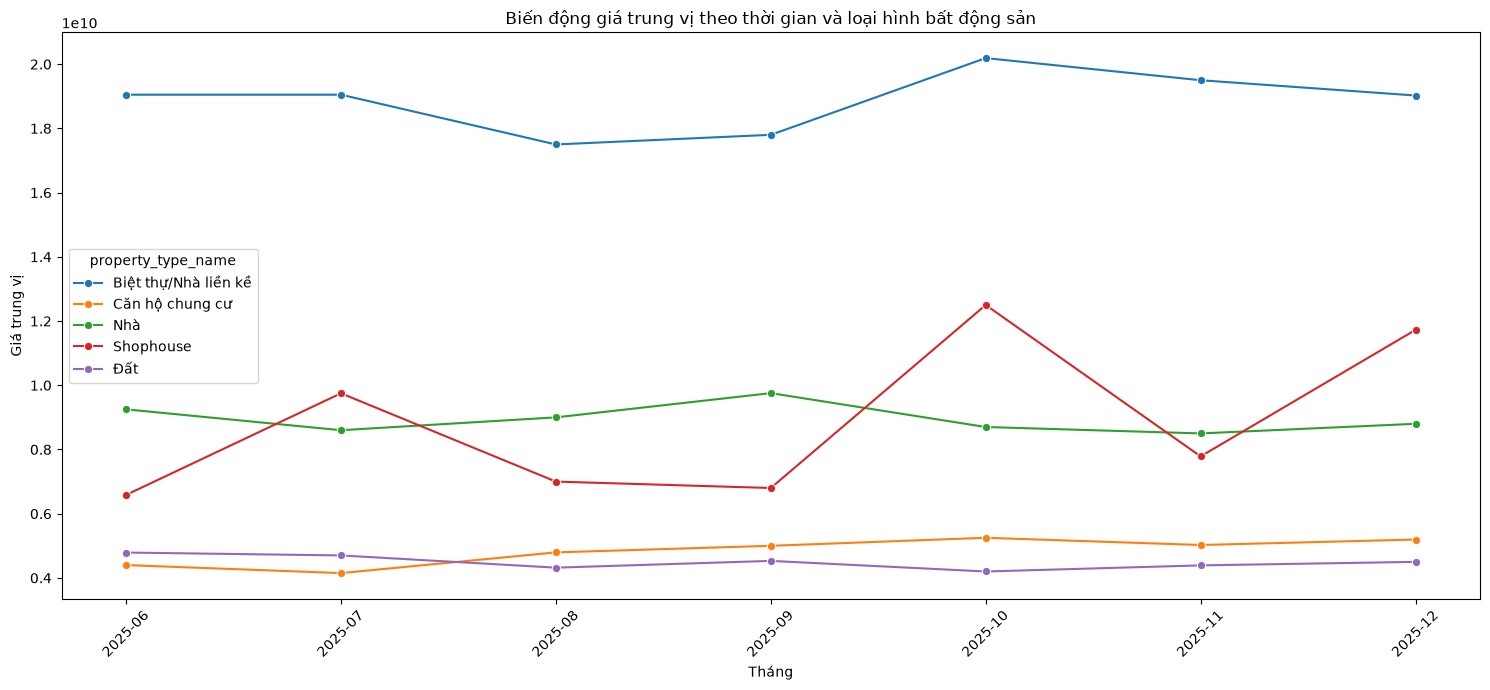

In [48]:
plt.figure(figsize=(15, 7))

sns.lineplot(
    data=monthly_type_price,
    x="year_month",
    y="median_price",
    hue="property_type_name",
    marker="o"
)

plt.title("Biến động giá trung vị theo thời gian và loại hình bất động sản")
plt.xlabel("Tháng")
plt.ylabel("Giá trung vị")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

nhìn vào biểu đồ này thì ta thấy: 
- giá của loại bds biệt thự/nhà liền kề có sự chênh lệch rõ  ràng, giá biến động kha khá, trong vòng nữa năm thì thấy giá không tăng giảm quá nhiều
- nhóm nhà và shophouse có tập trung ở mức trung bình trong 5 loại bds, với giá  nhà thì biến động nhẹ, không có tăng giảm mạnh, còn shophouse thì biến động mạnh, tăng giảm nhiều vào giao đoạn ở cuối năm.
- nhóm căn hộ chung cư, đất thuộc nhóm giá trị thấp nhất trong 5 loại hình bds, với giá không có biến động nhiều, chủ yếu là giữ nguyên hoặc tăng giảm rất ít

# Phân tích Phân khúc Thị trường và Dự án (Market Segmentation)

-	Loại hình bất động sản nào (property_type_name như Nhà, Đất, Biệt thự/Nhà liền kề) chiếm số lượng lớn nhất và có mức giá trị cao nhất?

In [49]:
property_type_stats = (
    df.groupby("property_type_name")
    .agg(
        listing_count=("name", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        mean_area=("area", "mean")
    )
    .reset_index()
    .sort_values("listing_count", ascending=False)
)

display(property_type_stats)

,property_type_name,listing_count,mean_price,median_price,mean_area
2,Nhà,4573,1.584096e+10,8.900000e+09,84.406766
4,Đất,2397,1.188287e+10,4.500000e+09,577.411063
1,Căn hộ chung cư,2100,6.762154e+09,4.850000e+09,81.735356
0,Biệt thự/Nhà liền kề,755,3.000460e+10,1.890000e+10,178.361974
3,Shophouse,170,1.471244e+10,8.900000e+09,110.833941


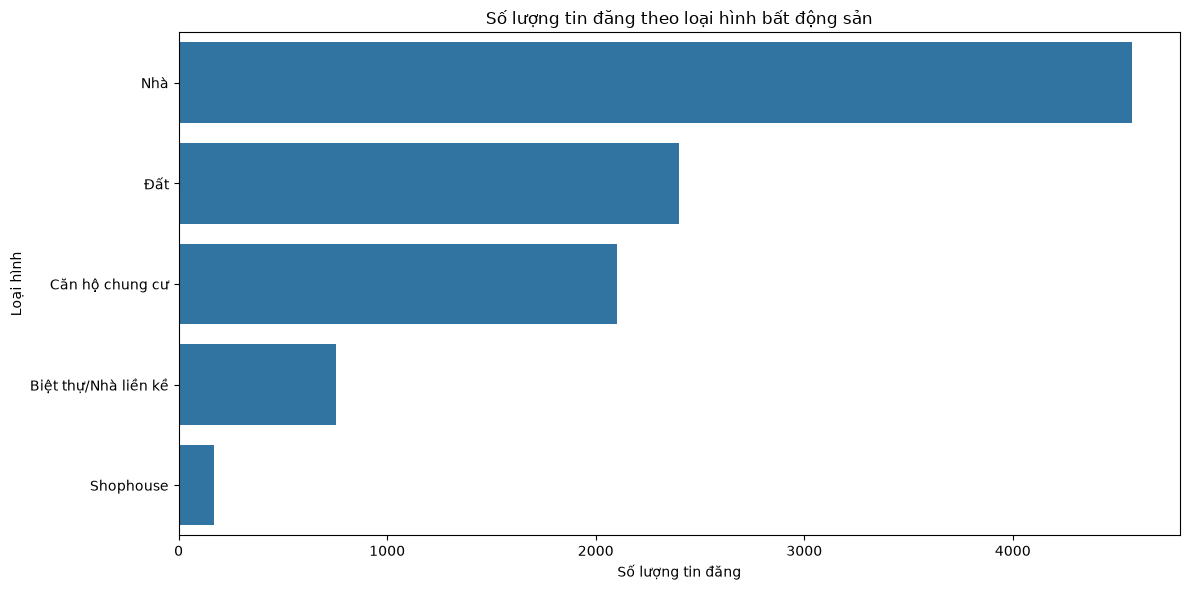

In [50]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=property_type_stats,
    x="listing_count",
    y="property_type_name"
)

plt.title("Số lượng tin đăng theo loại hình bất động sản")
plt.xlabel("Số lượng tin đăng")
plt.ylabel("Loại hình")

plt.tight_layout()
plt.show()

- nhà có số tin đăng lớn nhất trong 5 loại bds 
- đất và căn hộ chung cư với sô tin đăng ở mức giữa không quá nheiefu và cũng không quá ít
- biệt thự/nhà liền kề cũng ít 
- shophouse là ít nhất

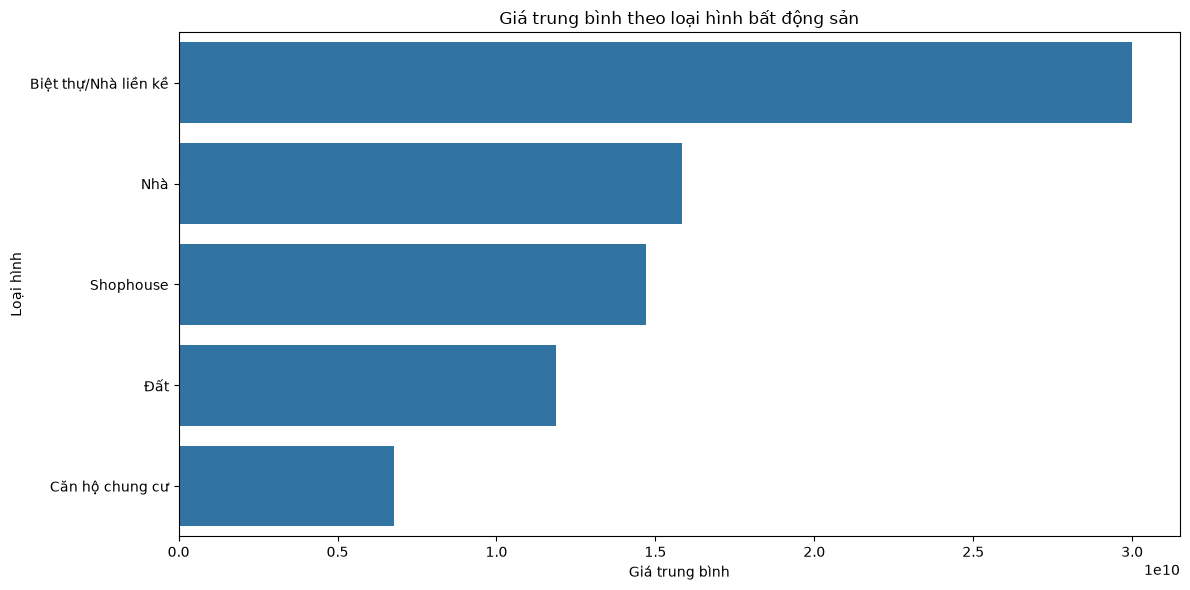

In [51]:
property_type_price = property_type_stats.sort_values(
    "mean_price",
    ascending=False
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=property_type_price,
    x="mean_price",
    y="property_type_name"
)

plt.title("Giá trung bình theo loại hình bất động sản")
plt.xlabel("Giá trung bình")
plt.ylabel("Loại hình")

plt.tight_layout()
plt.show()

Nhận xét:
- giá biệt thự/nhà liền kề cao gần như gấp đôi so với nhà và shophouse và cao phải gấp 3 lần so với căn hộ chung cư. cho thấy được mức độ xa xỉ của các Biệt thự/ nhà liền kề


-	Các dự án cụ thể nào (project_name) đang thu hút nhiều tin đăng nhất và phân khúc giá của chúng dao động trong khoảng nào?

In [52]:
project_count = (
    df["project_name"]
    .value_counts()
    .head(10)
    .reset_index()
)

project_count.columns = [
    "project_name",
    "listing_count"
]

display(project_count)

,project_name,listing_count
0,Vinhomes Ocean Park 2 – The Empire,56
1,Vinhomes Ocean Park,34
2,Sun Urban City Hà Nam,16
3,Khu đô thị Xa La,15
4,Vinhomes Global Gate (Vinhomes Cổ Loa),14
5,Peninsula Đà Nẵng (The Muse Đà Nẵng),12
6,Vinhomes Gardenia,12
7,Vinhomes Golden River,12
8,Centa City,11
9,Vinhomes Ocean Park 3,11


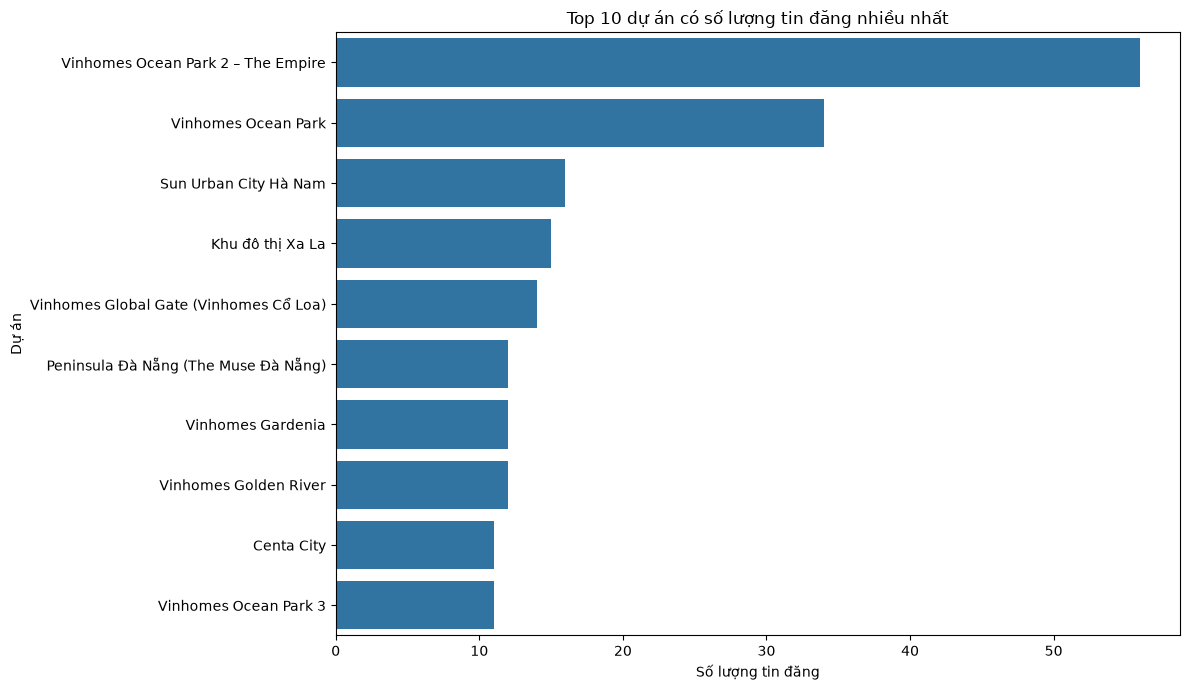

In [53]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=project_count,
    x="listing_count",
    y="project_name"
)

plt.title("Top 10 dự án có số lượng tin đăng nhiều nhất")
plt.xlabel("Số lượng tin đăng")
plt.ylabel("Dự án")

plt.tight_layout()
plt.show()

nhận xét:
- ở đây ta thấy rõ được mức độ mua bán các căn vinhome nó lớn như thế nào so với các loại hình bds khác. thấy được xu hướng mua nhà của người dân nước ta hiện nay ở các thành phố chủ yếu tập trung vào các căn phòng trong vinhome là nhiều.

In [54]:
#Phân khúc giá của các dự án (lấy trong top 10 ở trên luôn)
top_projects = project_count["project_name"].tolist()

project_price = (
    df[df["project_name"].isin(top_projects)]
    .groupby("project_name")
    .agg(
        listing_count=("price", "count"),
        min_price=("price", "min"),
        q1_price=("price", lambda x: x.quantile(0.25)),
        median_price=("price", "median"),
        q3_price=("price", lambda x: x.quantile(0.75)),
        max_price=("price", "max"),
        mean_price=("price", "mean")
    )
    .reset_index()
    .sort_values("listing_count", ascending=False)
)

display(project_price)


,project_name,listing_count,min_price,q1_price,median_price,q3_price,max_price,mean_price
8,Vinhomes Ocean Park 2 – The Empire,50,6.880000e+09,9.462500e+09,1.145000e+10,1.495000e+10,3.544000e+10,1.323980e+10
7,Vinhomes Ocean Park,30,2.300000e+09,3.187500e+09,4.055000e+09,8.072500e+09,9.500000e+10,1.189727e+10
1,Khu đô thị Xa La,15,2.300000e+09,3.600000e+09,3.790000e+09,5.750000e+09,5.500000e+10,1.013867e+10
3,Sun Urban City Hà Nam,12,1.100000e+09,1.520000e+09,2.900000e+09,5.112500e+09,1.790000e+10,4.360000e+09
6,Vinhomes Golden River,12,9.500000e+09,1.352500e+10,1.850000e+10,3.055000e+10,5.600000e+10,2.370000e+10
0,Centa City,11,4.500000e+09,7.210000e+09,8.900000e+09,1.425000e+10,1.890000e+10,1.076273e+10
4,Vinhomes Gardenia,10,5.000000e+09,7.025000e+09,8.750000e+09,1.147250e+10,5.700000e+10,1.353900e+10
5,Vinhomes Global Gate (Vinhomes Cổ Loa),10,3.700000e+09,1.645000e+10,2.240000e+10,2.550000e+10,7.790000e+10,2.826000e+10
2,Peninsula Đà Nẵng (The Muse Đà Nẵng),7,3.750000e+09,4.404000e+09,4.680000e+09,5.130000e+09,6.200000e+09,4.814000e+09
9,Vinhomes Ocean Park 3,7,1.180000e+10,1.625000e+10,1.698200e+10,2.004500e+10,2.300000e+10,1.776743e+10


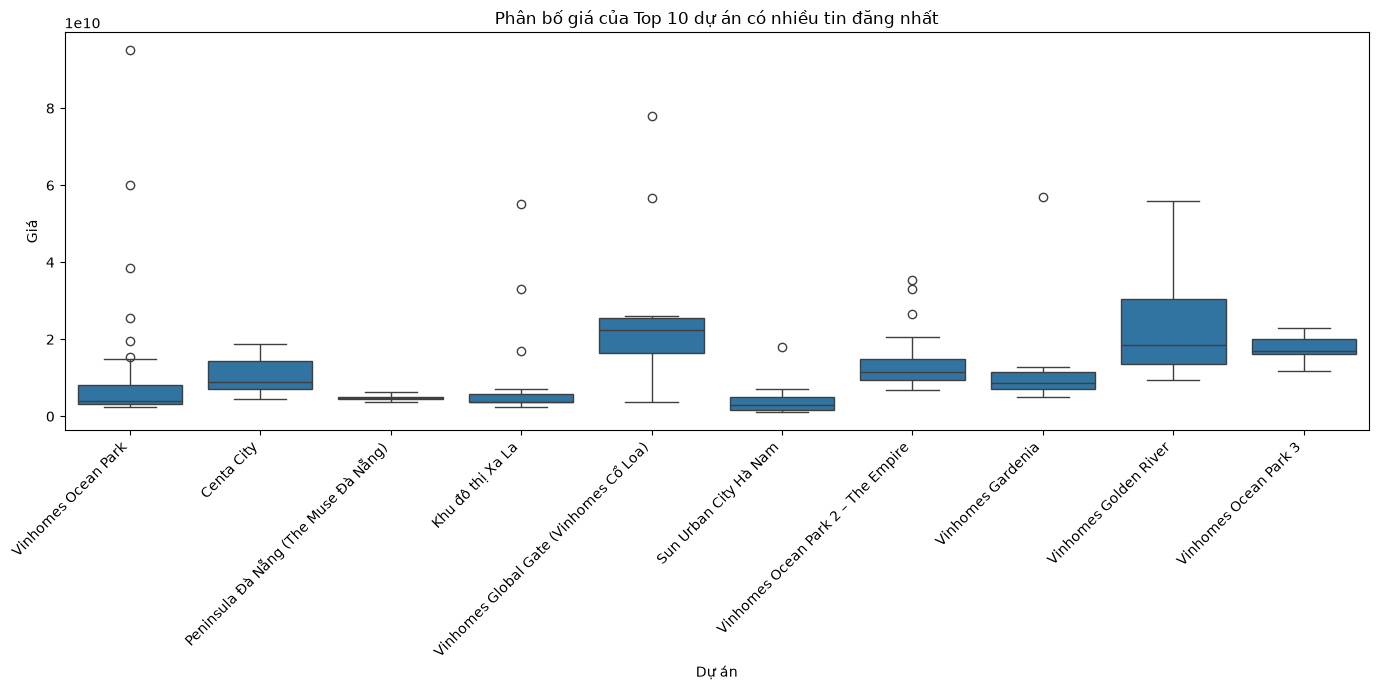

In [55]:
project_plot_data = df[
    df["project_name"].isin(top_projects) &
    df["price"].notna()
]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=project_plot_data,
    x="project_name",
    y="price"
)

plt.title("Phân bố giá của Top 10 dự án có nhiều tin đăng nhất")
plt.xlabel("Dự án")
plt.ylabel("Giá")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

Nhận xét:
Phân tích phân bố giá của Top 10 dự án có nhiều tin đăng nhất cho thấy thị trường bất động sản có sự phân hóa rõ rệt giữa các dự án. Các dự án thuộc nhóm Vinhomes, đặc biệt là Vinhomes Golden River và Vinhomes Global Gate, có mức giá trung vị cao hơn đáng kể so với các dự án còn lại. Đồng thời, sự xuất hiện của nhiều giá trị ngoại lệ cho thấy giá bất động sản trong cùng một dự án có thể dao động rất lớn do sự khác biệt về diện tích, vị trí, loại hình và các đặc điểm của từng bất động sản. Vì vậy, trong các bước phân tích và xây dựng mô hình dự đoán giá tiếp theo, cần xem xét xử lý outlier và ưu tiên sử dụng giá trung vị khi phân tích xu hướng giá.

-	Tỷ lệ các tin đăng thiếu thông tin quan trọng (price, floor_count, frontage_width) chiếm bao nhiêu phần trăm và ảnh hưởng thế nào đến độ tin cậy của dữ liệu?

In [56]:
# Tỷ lệ thiếu của price, floor_count, frontage_width
important_cols = [
    "price",
    "floor_count",
    "frontage_width"
]

missing_important = pd.DataFrame({
    "Thuộc tính": important_cols,
    "Số lượng thiếu": [
        df[col].isna().sum()
        for col in important_cols
    ],
    "Tỷ lệ thiếu (%)": [
        round(df[col].isna().mean() * 100, 2)
        for col in important_cols
    ]
})

display(missing_important)

,Thuộc tính,Số lượng thiếu,Tỷ lệ thiếu (%)
0,price,773,7.73
1,floor_count,7531,75.31
2,frontage_width,4804,48.04


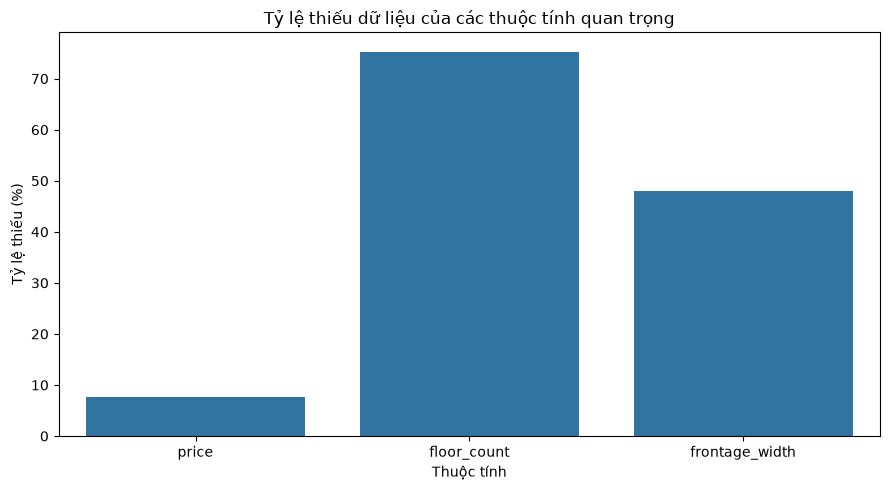

In [57]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=missing_important,
    x="Thuộc tính",
    y="Tỷ lệ thiếu (%)"
)

plt.title("Tỷ lệ thiếu dữ liệu của các thuộc tính quan trọng")
plt.xlabel("Thuộc tính")
plt.ylabel("Tỷ lệ thiếu (%)")

plt.tight_layout()
plt.show()

- tỉ lệ thiếu số tầng của các nhà thì rất là cao. nhưng đây là nó gom cả các loại bds lại với nhau, như đất hay các căn chung cư thì đâu có đếm được số tầng nên mức độ ảnh hưởng này không có quan trọng

In [58]:
# xem kỹ với all features
model_features = [
    "price",
    "area",
    "floor_count",
    "frontage_width",
    "road_width",
    "bedroom_count",
    "bathroom_count",
    "house_direction",
    "balcony_direction",
    "district_name",
    "ward_name",
    "property_type_name",
    "project_name"
]

data_quality = pd.DataFrame({
    "column": model_features,
    "missing_count": [
        df[col].isna().sum()
        for col in model_features
    ],
    "missing_percent": [
        round(df[col].isna().mean() * 100, 2)
        for col in model_features
    ]
}).sort_values(
    "missing_percent",
    ascending=False
)

display(data_quality)

,column,missing_count,missing_percent
8,balcony_direction,8445,84.45
4,road_width,7998,79.98
2,floor_count,7531,75.31
12,project_name,7237,72.37
7,house_direction,6949,69.49
6,bathroom_count,4933,49.33
3,frontage_width,4804,48.04
5,bedroom_count,4584,45.84
10,ward_name,1430,14.30
0,price,773,7.73


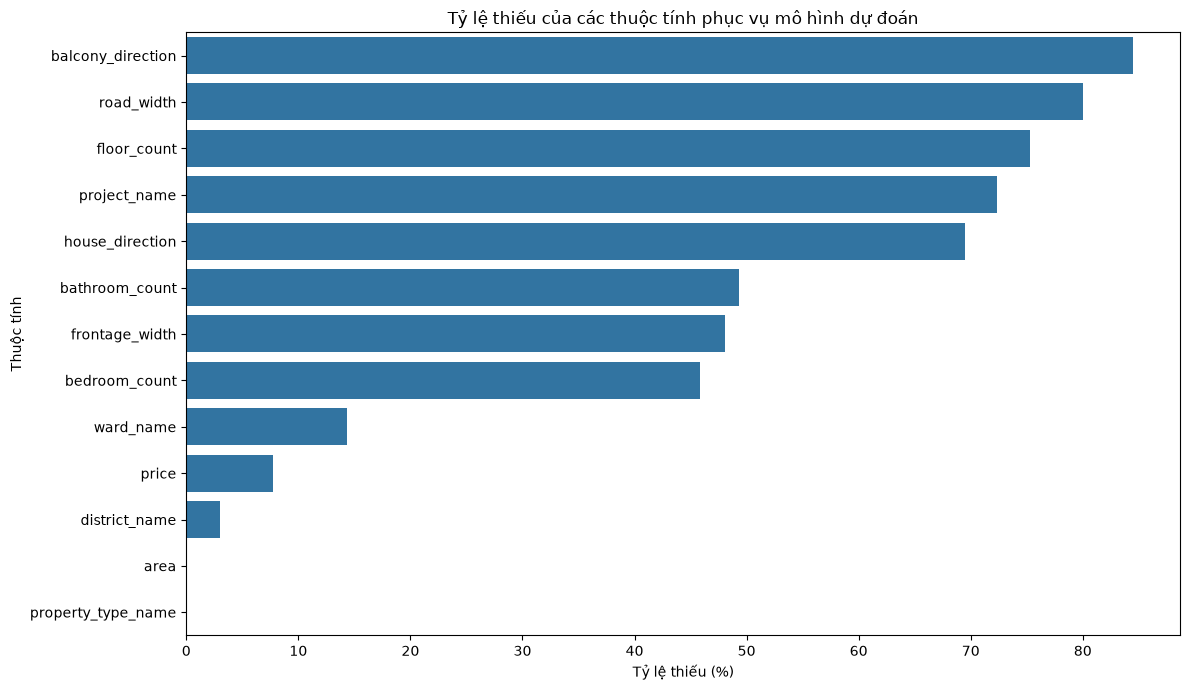

In [59]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=data_quality,
    x="missing_percent",
    y="column"
)

plt.title("Tỷ lệ thiếu của các thuộc tính phục vụ mô hình dự đoán")
plt.xlabel("Tỷ lệ thiếu (%)")
plt.ylabel("Thuộc tính")

plt.tight_layout()
plt.show()

- với các features như: ban công, độ rộng mặt đường, tên dự án thì độ thiếu rất nhiều, nhưng nó đã tính luôn với các loại hình bds khác nên mức độ miss của nó khá là cao và nó cũng ảnh hưởng khá là ít đến giá trị của bds.
- với các loại bds như đất,... thì nó lại không cso số phòng ngủ, phòng tắm nên nó cũng làm tăng tỉ lệ miss trong bộ data. 

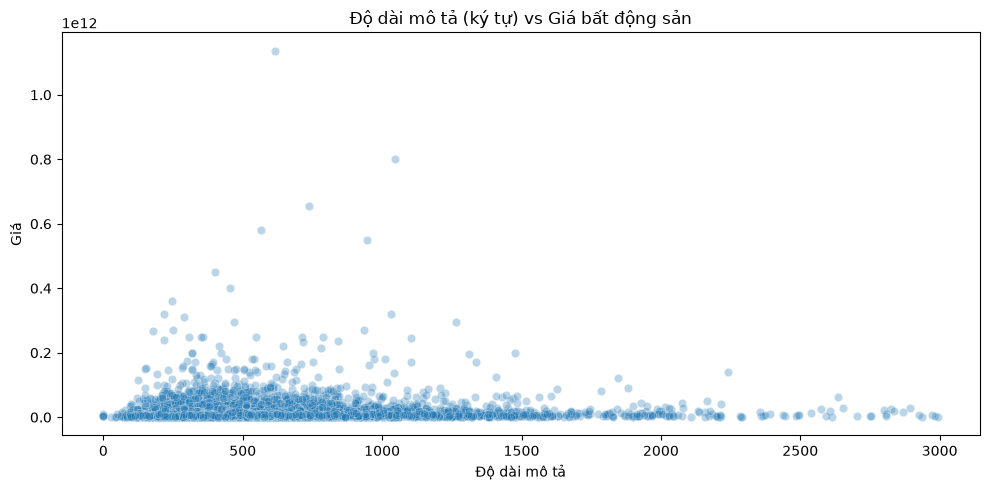

Tương quan (Spearman) giữa độ dài mô tả và giá: 0.085


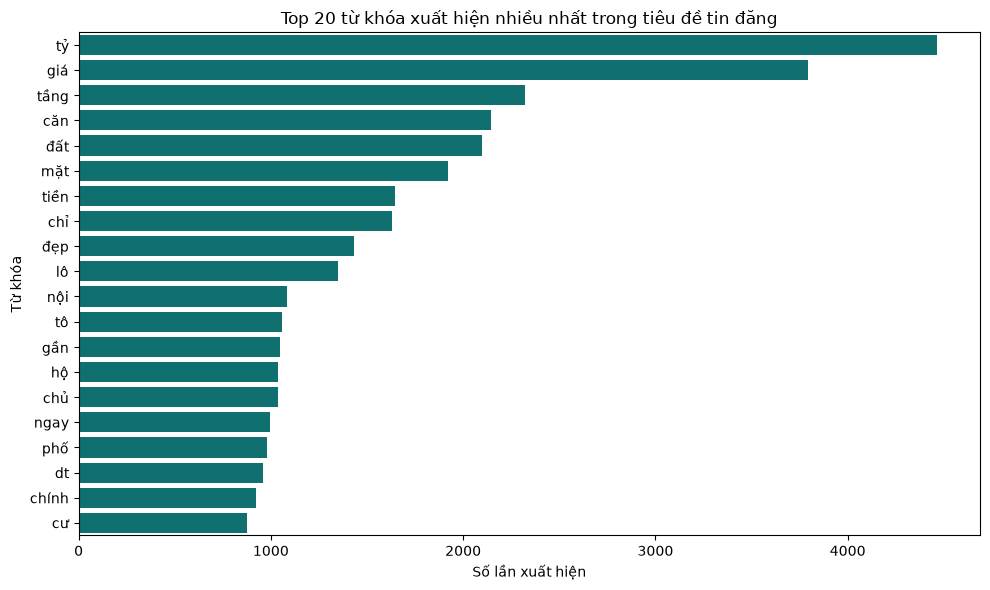

In [60]:
# PHÂN TÍCH VĂN BẢN: name & description
# Độ dài mô tả và mối liên hệ với giá
df['description_len'] = df['description'].fillna('').apply(len)
 
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df[df['price'].notna()],
    x='description_len',
    y='price',
    alpha=0.3
)
plt.title("Độ dài mô tả (ký tự) vs Giá bất động sản")
plt.xlabel("Độ dài mô tả")
plt.ylabel("Giá")
plt.tight_layout()
plt.show()
 
print("Tương quan (Spearman) giữa độ dài mô tả và giá:",
      round(df[['description_len', 'price']].corr(method='spearman').iloc[0, 1], 3))
 
# Tần suất từ khóa xuất hiện trong tên tin đăng (name)
def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\sÀ-ỹ]', ' ', text)  # giữ chữ tiếng Việt có dấu
    return text.split()
 
all_words = []
for name in df['name'].dropna():
    all_words.extend(clean_and_tokenize(name))
 
# Loại bỏ các từ dừng (stopword) phổ biến, đơn giản hóa
stopwords_vn = {'và', 'của', 'cho', 'tại', 'có', 'với', 'là', 'nhà', 'bán',
                'cần', 'the', 'a', 'to', 'in', 'trong', 'đường', 'khu'}
filtered_words = [w for w in all_words if w not in stopwords_vn and len(w) > 1]
 
word_freq = Counter(filtered_words).most_common(20)
word_freq_df = pd.DataFrame(word_freq, columns=['word', 'count'])
 
plt.figure(figsize=(10, 6))
sns.barplot(data=word_freq_df, x='count', y='word', color='teal')
plt.title("Top 20 từ khóa xuất hiện nhiều nhất trong tiêu đề tin đăng")
plt.xlabel("Số lần xuất hiện")
plt.ylabel("Từ khóa")
plt.tight_layout()
plt.show()

Độ dài mô tả gần như không liên quan đến giá (tương quan Spearman chỉ 0.085) — tin dài hay ngắn không phản ánh giá trị BĐS, có lẽ phụ thuộc thói quen viết tin hơn là đặc điểm sản phẩm. Về từ khóa tiêu đề, các từ xuất hiện nhiều nhất ("tỷ", "giá", "tầng", "căn", "đất", "mặt", "tiền") phản ánh đúng nội dung tin rao. Đáng chú ý, cụm từ quan trọng như "mặt tiền" hay "chính chủ" đang bị tách rời thành từ đơn lẻ do tokenizer chỉ tách theo khoảng trắng — nếu muốn khai thác sâu hơn nên trích theo cụm 2 từ (bigram).

Nhận xét chung:

- Giá bất động sản trong bộ dữ liệu có độ lệch phải rất mạnh (skewness ~14), phần lớn tin đăng tập trung ở mức giá thấp-trung bình, trong khi một số ít BĐS cao cấp (biệt thự, dự án Vinhomes) kéo dài đuôi phân phối. Log-transform giá là bước xử lý cần thiết trước khi mô hình hoá.

- Các yếu tố ảnh hưởng rõ rệt và có ý nghĩa thống kê đến giá gồm: loại hình BĐS (ANOVA p<0.001), vị trí địa lý — tỉnh/thành và có mặt tiền hay không (t-test p<0.001), và số phòng ngủ/phòng tắm (tương quan 0.58–0.61 với giá — mạnh hơn cả diện tích thô).

- Một số yếu tố tưởng chừng quan trọng nhưng thực tế ảnh hưởng yếu hoặc chưa rõ ràng về mặt thống kê: độ rộng đường trước nhà, hướng nhà (p≈0.052 - cận biên), và độ dài mô tả tin đăng.
Dữ liệu có tỷ lệ thiếu cao ở các trường đặc thù theo loại hình BĐS (house_depth, 
floor_count, project_name...) — phần lớn là thiếu có hệ thống (structural missing) do khác biệt bản chất giữa các loại BĐS, không phải lỗi thu thập dữ liệu, nên cần xử lý theo từng nhóm property_type_name riêng thay vì impute chung toàn bộ dữ liệu.

- Hướng xử lý tiếp theo cho bước tiền xử lý/modeling: (1) loại bỏ/kiểm tra thủ công các outlier do lỗi nhập liệu (bedroom/bathroom > 20, area bất thường); (2) dùng log(price) làm biến mục tiêu; (3) cẩn trọng với đa cộng tuyến giữa bedroom_count và bathroom_count; (4) cân nhắc encode riêng theo loại hình BĐS vì đặc trư